# Lab03: Phân tích khám phá dữ liệu (EDA) - Ames Housing / Kaggle House Prices



# PHẦN 1: XÁC ĐỊNH TÍNH CHẤT DỮ LIỆU 


# Xác định tính chất dữ liệu

## 1. Import thư viện

In [71]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')


## 2. Nạp dữ liệu

> Tải `train.csv` và `test.csv` từ Kaggle về
>


In [72]:
import os
import glob

def find_data_dir():
    candidates = [
        "./",
        "../input/house-prices-advanced-regression-techniques/",
        "/kaggle/input/house-prices-advanced-regression-techniques/",
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "train.csv")):
            return c

    # Fallback: quét toàn bộ /kaggle/input/ để tự tìm train.csv,
    # phòng trường hợp tên thư mục dataset khác tên competition
    hits = glob.glob("/kaggle/input/**/train.csv", recursive=True)
    if hits:
        return os.path.dirname(hits[0]) + "/"

    raise FileNotFoundError(
        "Không tìm thấy train.csv.\n"
        "- Nếu chạy local: tải train.csv/test.csv từ Kaggle rồi đặt cùng thư mục notebook.\n"
        "- Nếu chạy trên Kaggle: bấm nút 'Add Input' (góc phải) -> tìm và thêm dataset/competition "
        "'house-prices-advanced-regression-techniques' -> chạy lại cell này."
    )

DATA_DIR = find_data_dir()
print("Đang dùng DATA_DIR =", DATA_DIR)

train = pd.read_csv(DATA_DIR + "train.csv")
test = pd.read_csv(DATA_DIR + "test.csv")

print("Kích thước train:", train.shape)
print("Kích thước test :", test.shape)

Đang dùng DATA_DIR = /kaggle/input/competitions/house-prices-advanced-regression-techniques/
Kích thước train: (1460, 81)
Kích thước test : (1459, 80)


In [73]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Thông tin tổng quan (dtype, non-null count)

In [74]:
train.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 4. Phân loại biến theo 4 nhóm tính chất

Dữ liệu thô đọc bằng pandas chỉ phân biệt được `int64`, `float64`, `object` — **không phản ánh đúng bản chất thống kê** của biến
(ví dụ `MSSubClass` là số nguyên nhưng thực chất là biến định danh - nominal; `OverallQual` là số nguyên nhưng là biến thứ bậc - ordinal).

Do đó ta khai báo tường minh 4 nhóm biến theo tài liệu mô tả dữ liệu của tác giả (`DataDocumentation.txt`), tương tự phân loại 23/23/14/20 trong paper (áp dụng cho 79 biến giải thích của bản Kaggle, `Id` và `SalePrice` không tính vào 4 nhóm).

In [75]:
# --- Biến định danh (Nominal) ---
nominal_vars = [
    'MSSubClass','MSZoning','Street','Alley','LandContour','LotConfig',
    'Neighborhood','Condition1','Condition2','BldgType','HouseStyle',
    'RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
    'Foundation','Heating','CentralAir','GarageType','MiscFeature',
    'SaleType','SaleCondition'
]

# --- Biến thứ bậc (Ordinal) ---
ordinal_vars = [
    'LotShape','Utilities','LandSlope','OverallQual','OverallCond',
    'ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2','HeatingQC','Electrical','KitchenQual',
    'Functional','FireplaceQu','GarageFinish','GarageQual','GarageCond',
    'PavedDrive','PoolQC','Fence'
]

# --- Biến rời rạc (Discrete) ---
discrete_vars = [
    'YearBuilt','YearRemodAdd','BsmtFullBath','BsmtHalfBath','FullBath',
    'HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces',
    'GarageYrBlt','GarageCars','MoSold','YrSold'
]

# --- Biến liên tục (Continuous) ---
continuous_vars = [
    'LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
    'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
    'GrLivArea','GarageArea','WoodDeckSF','OpenPorchSF','EnclosedPorch',
    '3SsnPorch','ScreenPorch','PoolArea','MiscVal'
]

print(f"Nominal   : {len(nominal_vars)} biến")
print(f"Ordinal   : {len(ordinal_vars)} biến")
print(f"Discrete  : {len(discrete_vars)} biến")
print(f"Continuous: {len(continuous_vars)} biến")
print(f"Tổng      : {len(nominal_vars)+len(ordinal_vars)+len(discrete_vars)+len(continuous_vars)} biến "
      f"(kỳ vọng 79 biến giải thích trong bản Kaggle)")


Nominal   : 23 biến
Ordinal   : 23 biến
Discrete  : 14 biến
Continuous: 19 biến
Tổng      : 79 biến (kỳ vọng 79 biến giải thích trong bản Kaggle)


In [76]:
all_grouped = nominal_vars + ordinal_vars + discrete_vars + continuous_vars
feature_cols = [c for c in train.columns if c not in ('Id', 'SalePrice')]

missing_in_groups = set(feature_cols) - set(all_grouped)
extra_in_groups = set(all_grouped) - set(feature_cols)

print("Cột có trong dữ liệu nhưng CHƯA được phân nhóm:", missing_in_groups)
print("Cột được phân nhóm nhưng KHÔNG có trong dữ liệu:", extra_in_groups)


Cột có trong dữ liệu nhưng CHƯA được phân nhóm: set()
Cột được phân nhóm nhưng KHÔNG có trong dữ liệu: set()


> **Lưu ý:** Nếu 2 tập ở trên rỗng nghĩa là việc phân loại đã khớp 100% với 79 biến giải thích của tập Kaggle.
> Nếu có chênh lệch nhỏ so với 23/23/14/20 của paper gốc — đó là vì bản Kaggle chỉ giữ 79/80 biến (loại bớt một số biến tính toán nội bộ của Assessor's Office).

## 5. Biến mục tiêu (Target variable): `SalePrice`

In [77]:
print("Kiểu dữ liệu :", train['SalePrice'].dtype)
print("Số quan sát  :", train['SalePrice'].count())
train['SalePrice'].describe()


Kiểu dữ liệu : int64
Số quan sát  : 1460


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 6. Bảng tổng hợp tính chất từng biến (dtype gốc vs nhóm phân loại)

In [78]:
def get_group(col):
    if col in nominal_vars: return 'Nominal'
    if col in ordinal_vars: return 'Ordinal'
    if col in discrete_vars: return 'Discrete'
    if col in continuous_vars: return 'Continuous'
    return 'Chưa phân loại'

summary = pd.DataFrame({
    'column': feature_cols,
    'pandas_dtype': [train[c].dtype for c in feature_cols],
    'n_unique': [train[c].nunique() for c in feature_cols],
    'n_missing': [train[c].isna().sum() for c in feature_cols],
    'group': [get_group(c) for c in feature_cols]
})
summary.sort_values('group').reset_index(drop=True)


,column,pandas_dtype,n_unique,n_missing,group
0,TotalBsmtSF,int64,721,0,Continuous
1,MasVnrArea,float64,327,8,Continuous
2,BsmtUnfSF,int64,780,0,Continuous
3,GrLivArea,int64,861,0,Continuous
4,LowQualFinSF,int64,24,0,Continuous
5,2ndFlrSF,int64,417,0,Continuous
6,GarageArea,int64,441,0,Continuous
7,WoodDeckSF,int64,274,0,Continuous
8,EnclosedPorch,int64,120,0,Continuous
9,OpenPorchSF,int64,202,0,Continuous


In [79]:
summary['group'].value_counts()


group
Nominal       23
Ordinal       23
Continuous    19
Discrete      14
Name: count, dtype: int64

## 7. Kết luận nhanh
- Đã nạp thành công `train.csv` (1460 dòng x 81 cột) và `test.csv` (1459 dòng x 80 cột).
- Đã phân loại 79 biến giải thích thành 4 nhóm tính chất (nominal / ordinal / discrete / continuous) bám sát paper của De Cock (2011).
- Bảng `summary` ở trên sẽ được dùng làm "bản đồ biến" (variable map) cho các notebook phân tích tiếp theo:
  - `02_Phan_Tich_Don_Bien.ipynb`
  - `03_Phan_Tich_Da_Bien.ipynb`
  - `04_Gia_Tri_Thieu_Mau_Bat_Thuong.ipynb`
  - `05_Xac_Dinh_Ngoai_Le.ipynb`


#  PHẦN 2: PHÂN TÍCH ĐƠN BIẾN 

# Phân tích đơn biến (Univariate Analysis)
Notebook này phân tích **từng biến riêng lẻ** trong bộ dữ liệu Ames Housing / Kaggle House Prices:
- Biến mục tiêu `SalePrice`: phân phối, độ lệch , độ nhọn , biến đổi log.
- Các biến liên tục : histogram + boxplot.
- Các biến rời rạc: countplot.
- Các biến thứ bậc: countplot theo thứ tự chất lượng.
- Các biến định danh: countplot theo tần suất.



## 1. Import thư viện & nạp dữ liệu

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

import os
import glob

def find_data_dir():
    candidates = [
        "./",
        "../input/house-prices-advanced-regression-techniques/",
        "/kaggle/input/house-prices-advanced-regression-techniques/",
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "train.csv")):
            return c

    # Fallback: quét toàn bộ /kaggle/input/ để tự tìm train.csv
    hits = glob.glob("/kaggle/input/**/train.csv", recursive=True)
    if hits:
        return os.path.dirname(hits[0]) + "/"

    raise FileNotFoundError(
        "Không tìm thấy train.csv.\n"
        "- Chạy: !ls /kaggle/input/  để xem đã add data chưa và tên thư mục là gì.\n"
        "- Nếu chưa có gì: bấm '+ Add Input' góc phải -> thêm competition "
        "'house-prices-advanced-regression-techniques'."
    )

DATA_DIR = find_data_dir()
print("Đang dùng DATA_DIR =", DATA_DIR)

train = pd.read_csv(DATA_DIR + "train.csv")
print("Kích thước train:", train.shape)

Đang dùng DATA_DIR = /kaggle/input/competitions/house-prices-advanced-regression-techniques/
Kích thước train: (1460, 81)


In [81]:
# Phân nhóm biến (đồng bộ với notebook 01)
nominal_vars = [
    'MSSubClass','MSZoning','Street','Alley','LandContour','LotConfig',
    'Neighborhood','Condition1','Condition2','BldgType','HouseStyle',
    'RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
    'Foundation','Heating','CentralAir','GarageType','MiscFeature',
    'SaleType','SaleCondition'
]
ordinal_vars = [
    'LotShape','Utilities','LandSlope','OverallQual','OverallCond',
    'ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2','HeatingQC','Electrical','KitchenQual',
    'Functional','FireplaceQu','GarageFinish','GarageQual','GarageCond',
    'PavedDrive','PoolQC','Fence'
]
discrete_vars = [
    'YearBuilt','YearRemodAdd','BsmtFullBath','BsmtHalfBath','FullBath',
    'HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces',
    'GarageYrBlt','GarageCars','MoSold','YrSold'
]
continuous_vars = [
    'LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
    'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
    'GrLivArea','GarageArea','WoodDeckSF','OpenPorchSF','EnclosedPorch',
    '3SsnPorch','ScreenPorch','PoolArea','MiscVal'
]


## 2. Phân tích biến mục tiêu `SalePrice`

Đây là bước quan trọng nhất vì đây là biến hồi quy (target). Nhiều mô hình tuyến tính giả định phần dư (residual) phân phối chuẩn,
nên độ lệch (skew) lớn của `SalePrice` thường gợi ý cần biến đổi log — đúng như gợi ý trong paper (mục 5: "taking a transformation (square root) of the sales price").

Skewness : 1.883
Kurtosis : 6.536


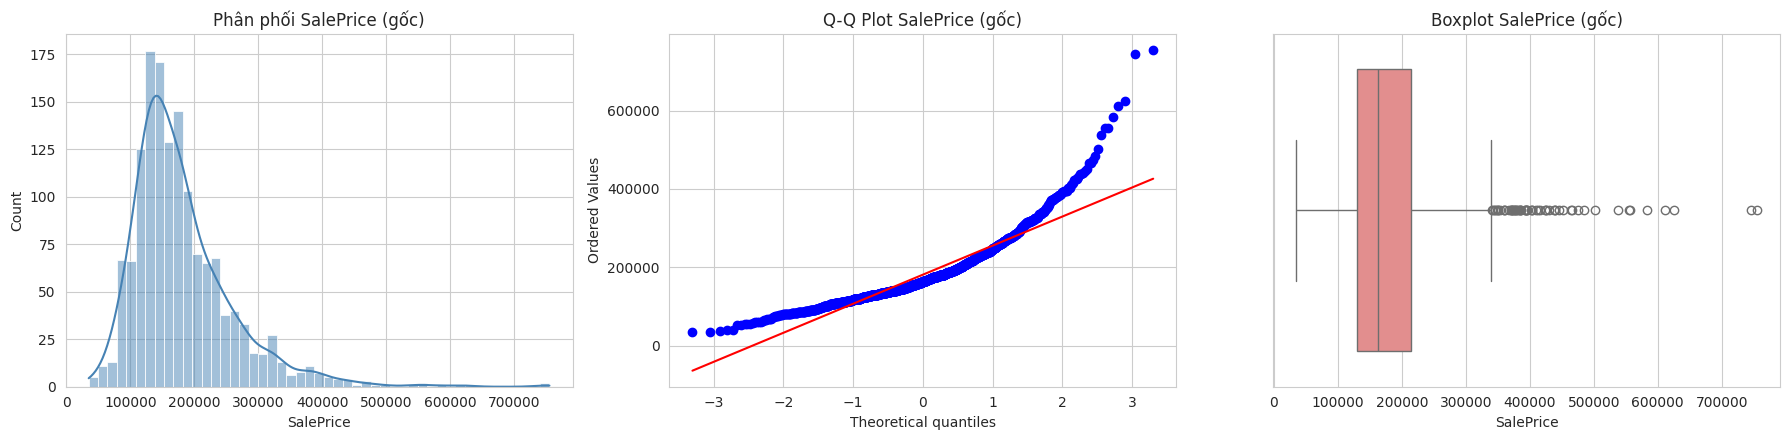

In [82]:
print(f"Skewness : {train['SalePrice'].skew():.3f}")
print(f"Kurtosis : {train['SalePrice'].kurt():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Phân phối SalePrice (gốc)')

stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title('Q-Q Plot SalePrice (gốc)')

sns.boxplot(x=train['SalePrice'], ax=axes[2], color='lightcoral')
axes[2].set_title('Boxplot SalePrice (gốc)')

plt.tight_layout()
plt.show()


Skewness sau log1p: 0.121
Kurtosis sau log1p: 0.810


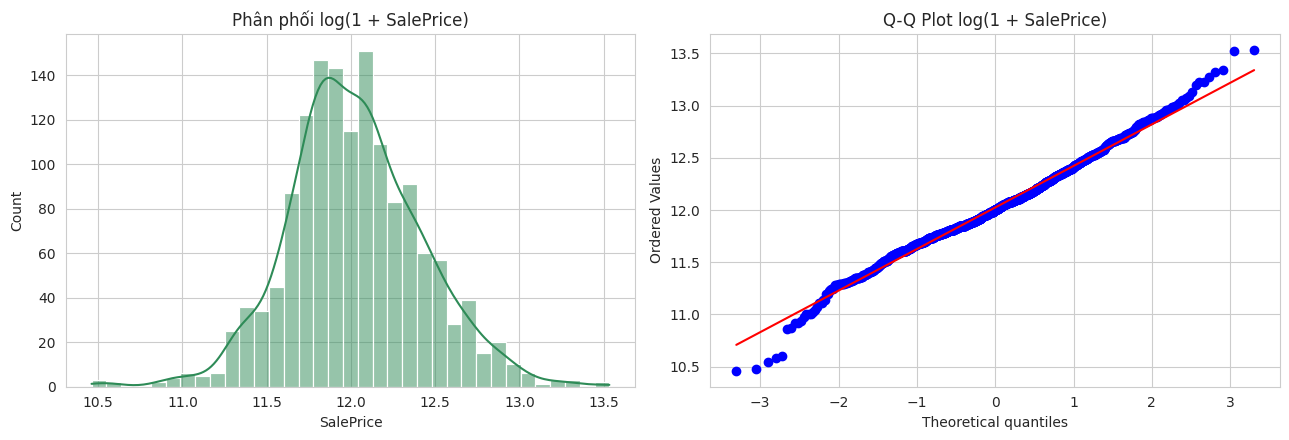

In [83]:
log_price = np.log1p(train['SalePrice'])
print(f"Skewness sau log1p: {log_price.skew():.3f}")
print(f"Kurtosis sau log1p: {log_price.kurt():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(log_price, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Phân phối log(1 + SalePrice)')
stats.probplot(log_price, plot=axes[1])
axes[1].set_title('Q-Q Plot log(1 + SalePrice)')
plt.tight_layout()
plt.show()


**Nhận xét:** `SalePrice` gốc lệch phải mạnh (skew dương lớn), sau khi biến đổi `log1p` phân phối gần với phân phối chuẩn hơn nhiều — hỗ trợ tốt hơn cho các giả định của hồi quy tuyến tính (MODEL1 trong paper).

## 3. Phân tích các biến liên tục (Continuous)

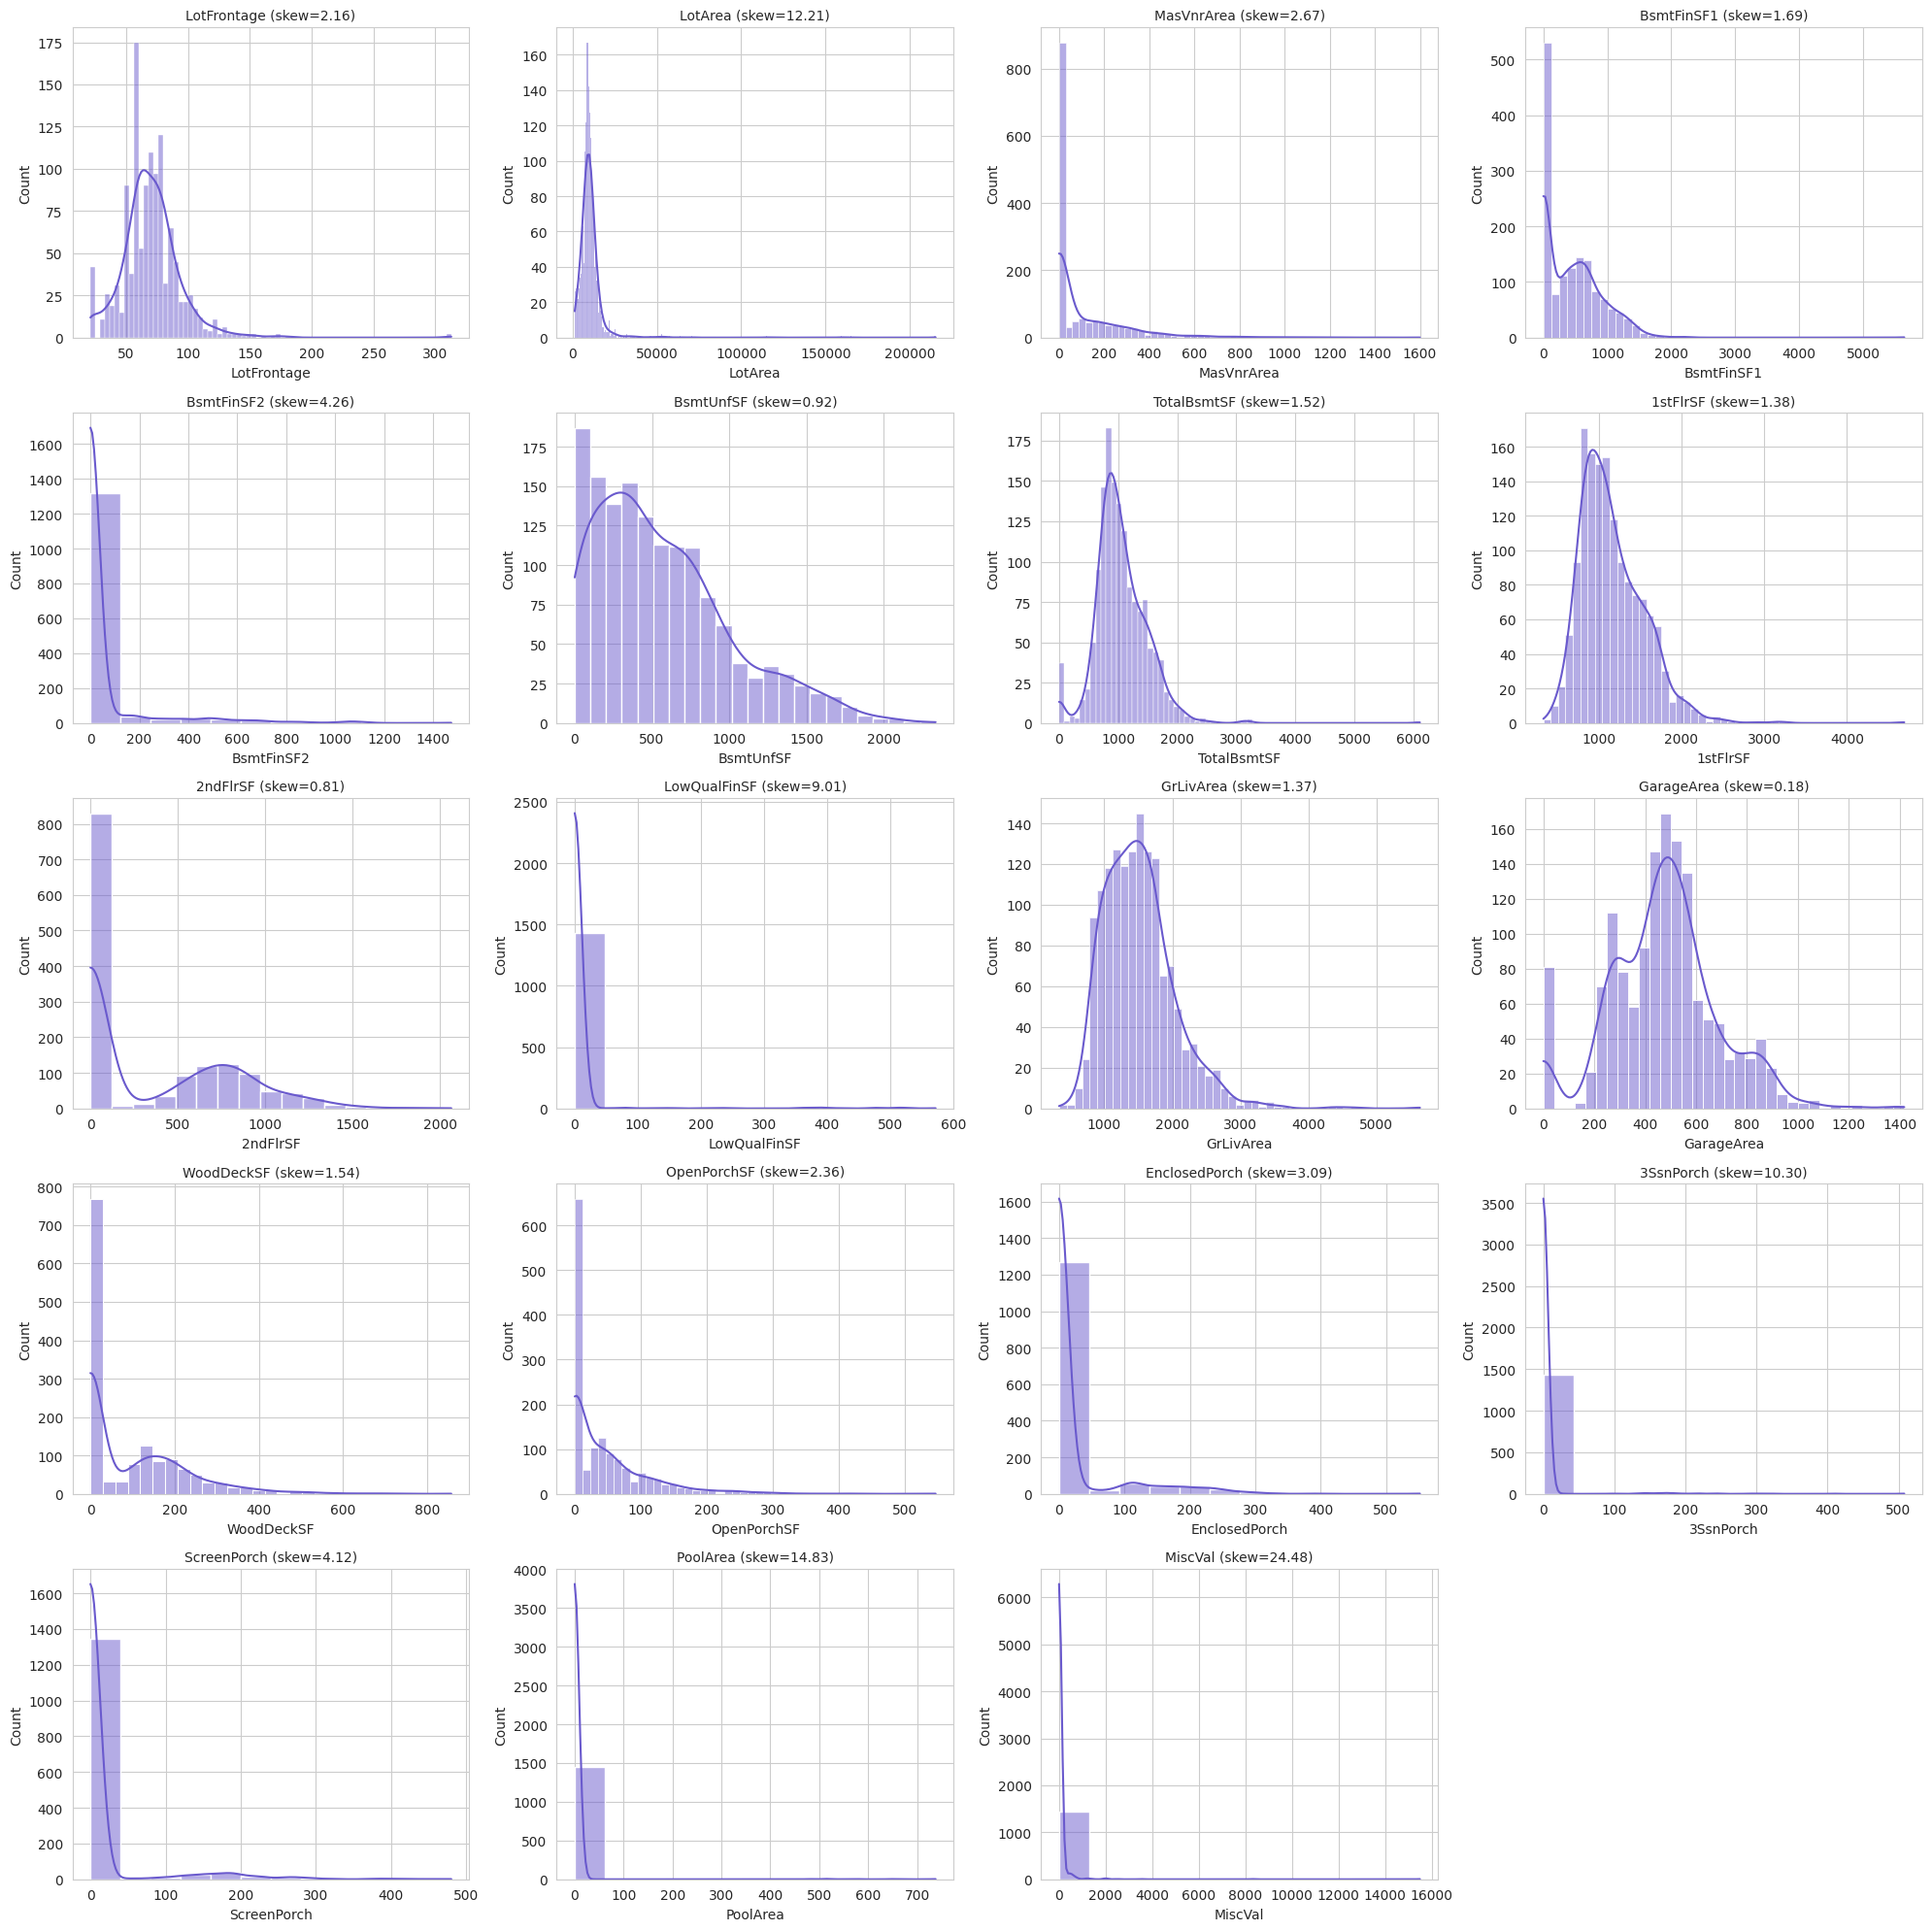

In [84]:
cont_available = [c for c in continuous_vars if c in train.columns]

n = len(cont_available)
ncols = 4
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cont_available):
    sns.histplot(train[col].dropna(), kde=True, ax=axes[i], color='slateblue')
    axes[i].set_title(f'{col} (skew={train[col].skew():.2f})', fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [85]:
train[cont_available].skew().sort_values(ascending=False).to_frame('skewness')


,skewness
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
BsmtFinSF2,4.255261
ScreenPorch,4.122214
EnclosedPorch,3.089872
MasVnrArea,2.669084
OpenPorchSF,2.364342


Boxplot để quan sát nhanh phạm vi giá trị & khả năng có ngoại lệ (sẽ phân tích chi tiết ở notebook 05):

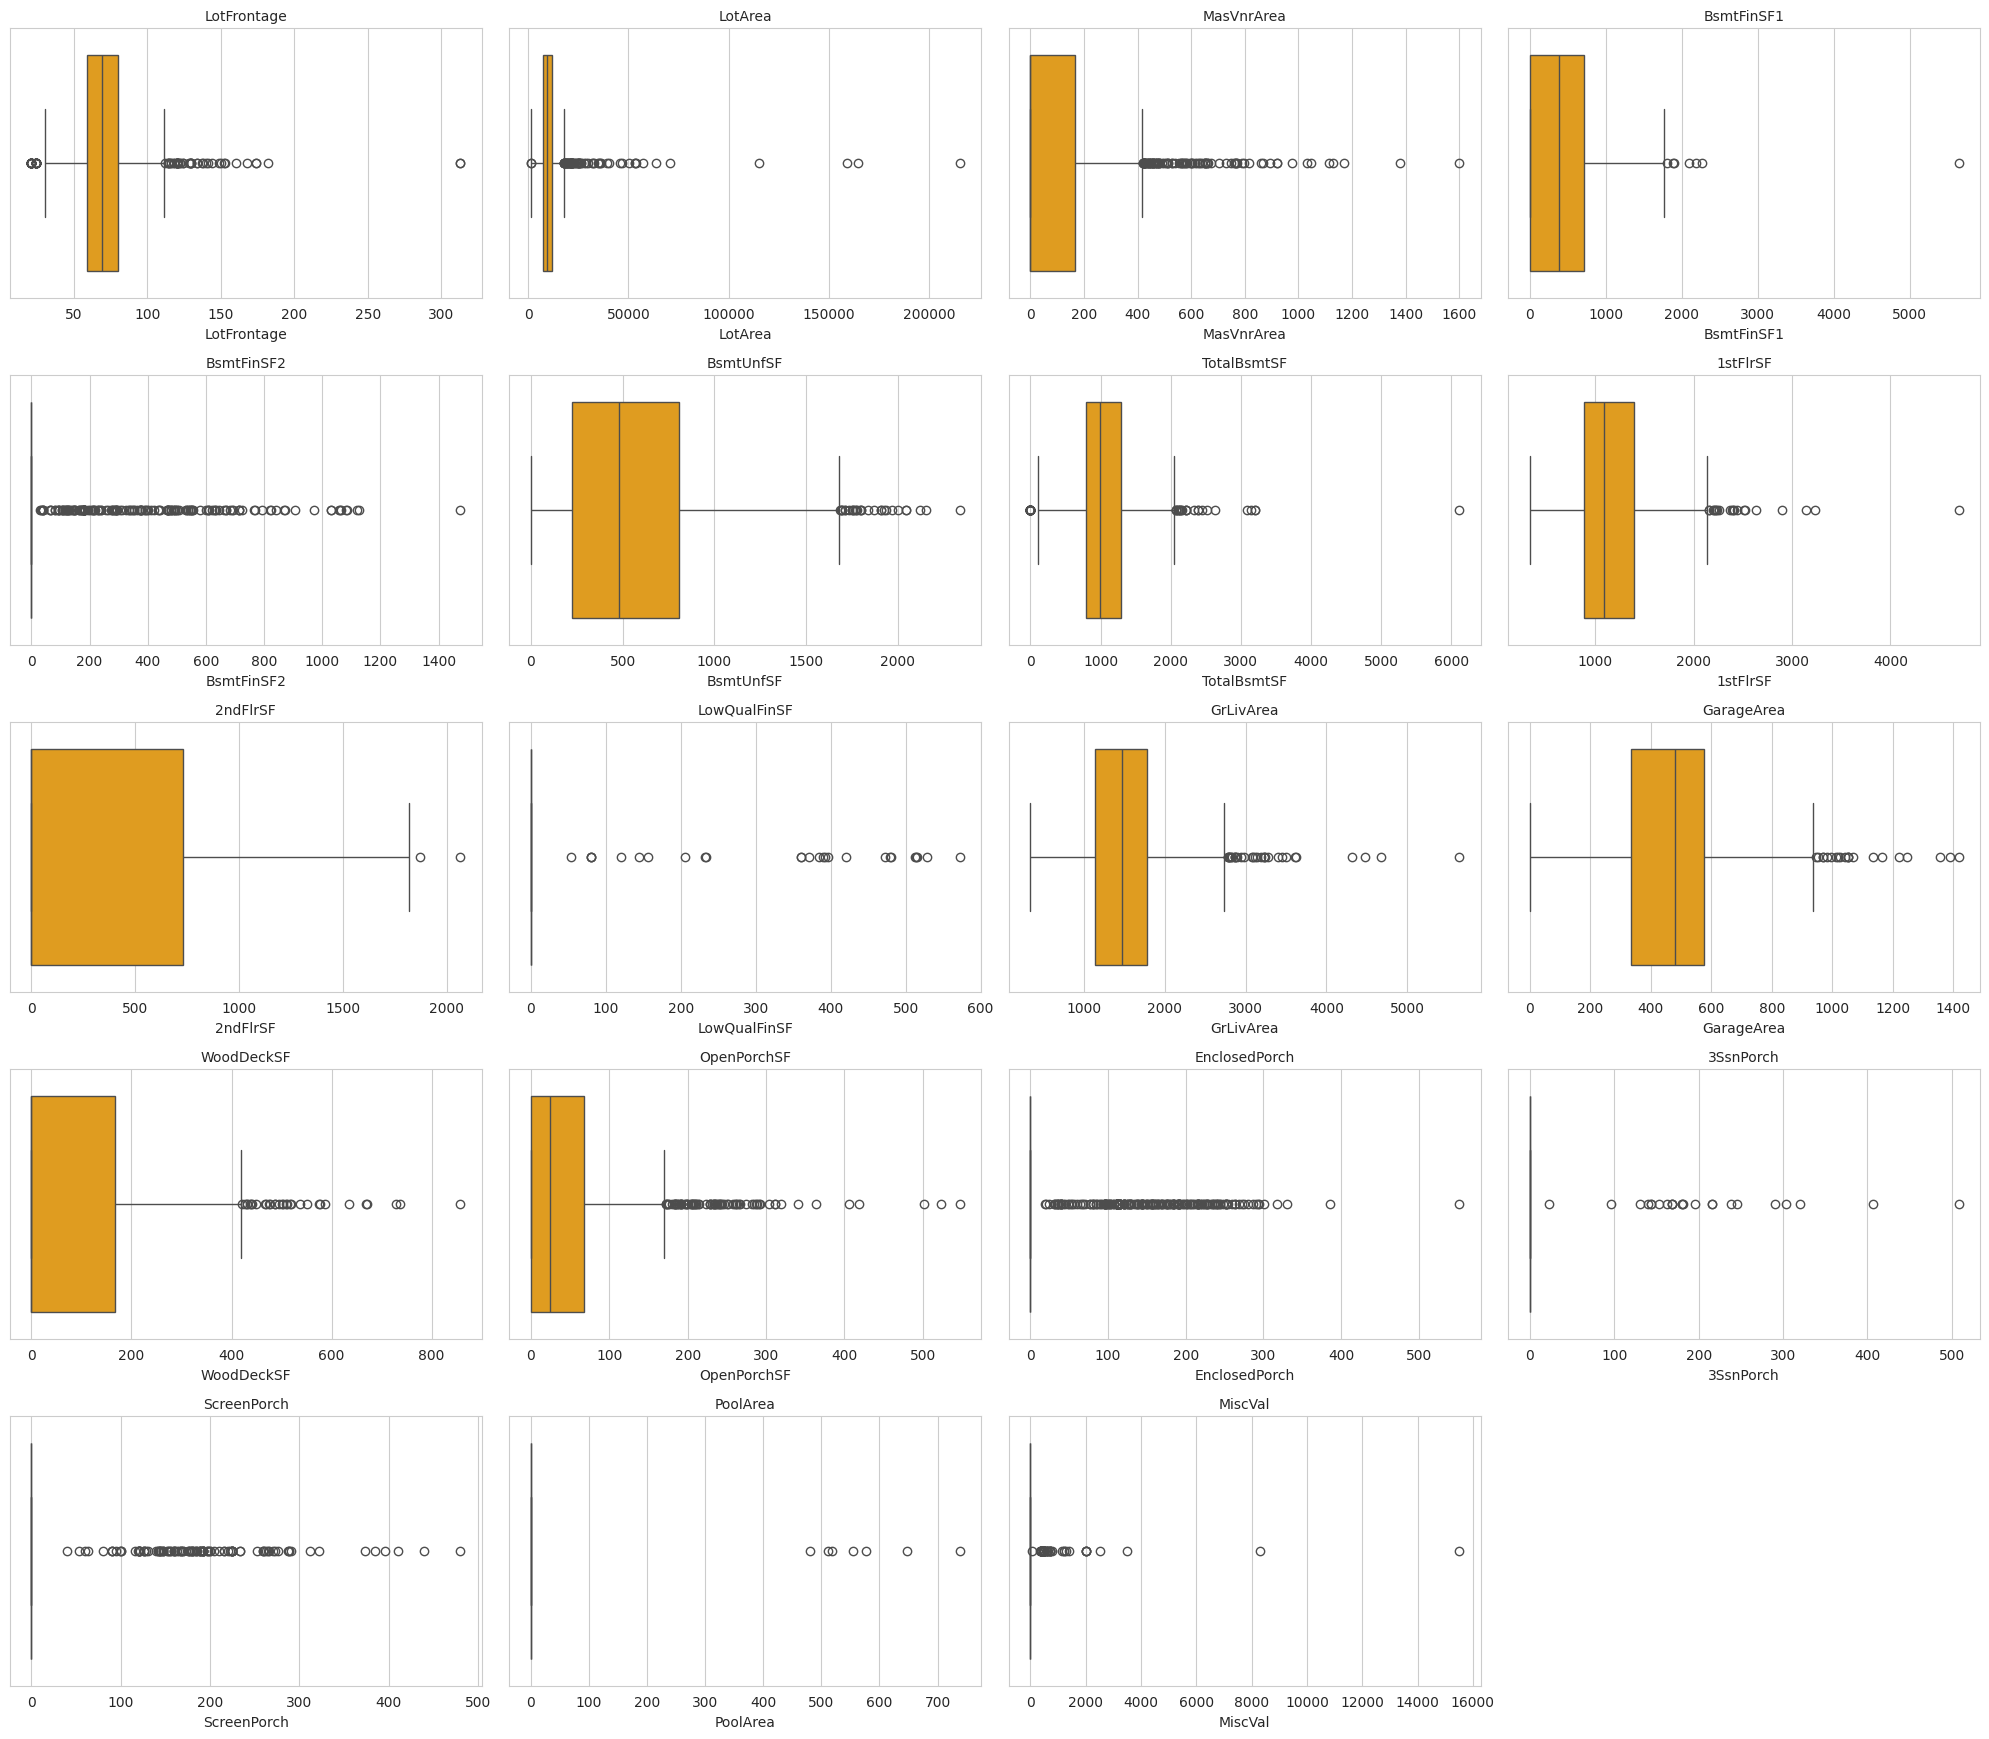

In [86]:
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.5*nrows))
axes = axes.flatten()
for i, col in enumerate(cont_available):
    sns.boxplot(x=train[col].dropna(), ax=axes[i], color='orange')
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


## 4. Phân tích các biến rời rạc

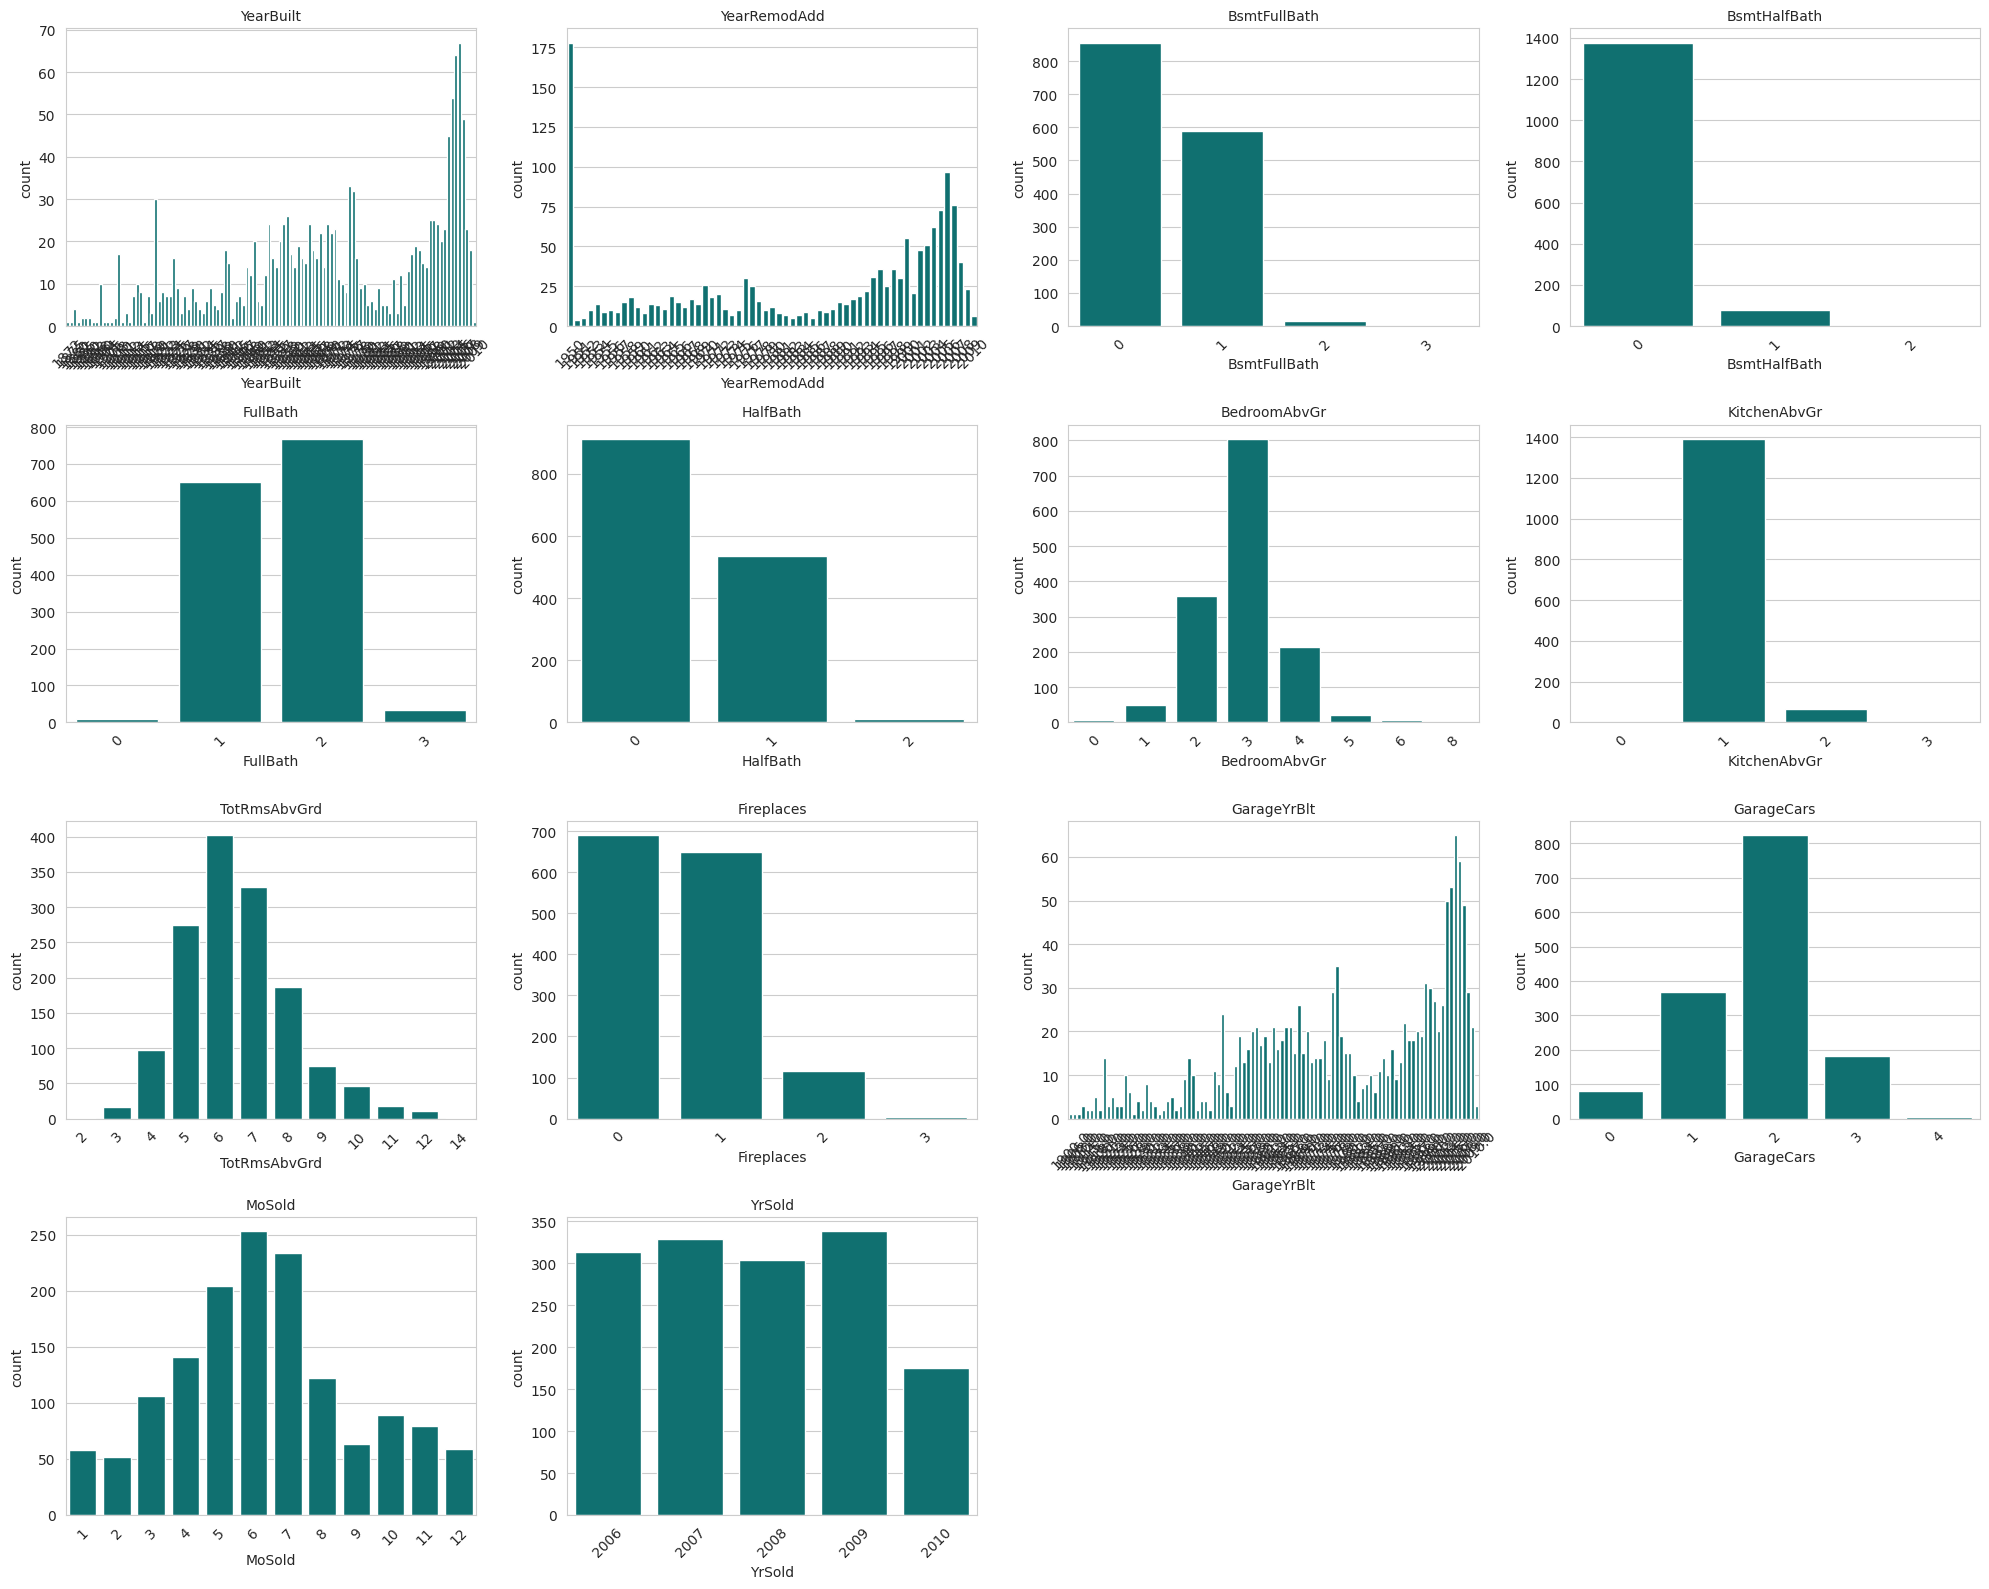

In [87]:
disc_available = [c for c in discrete_vars if c in train.columns]

n = len(disc_available)
ncols = 4
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(disc_available):
    sns.countplot(x=train[col], ax=axes[i], color='teal')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## 5. Phân tích các biến thứ bậc

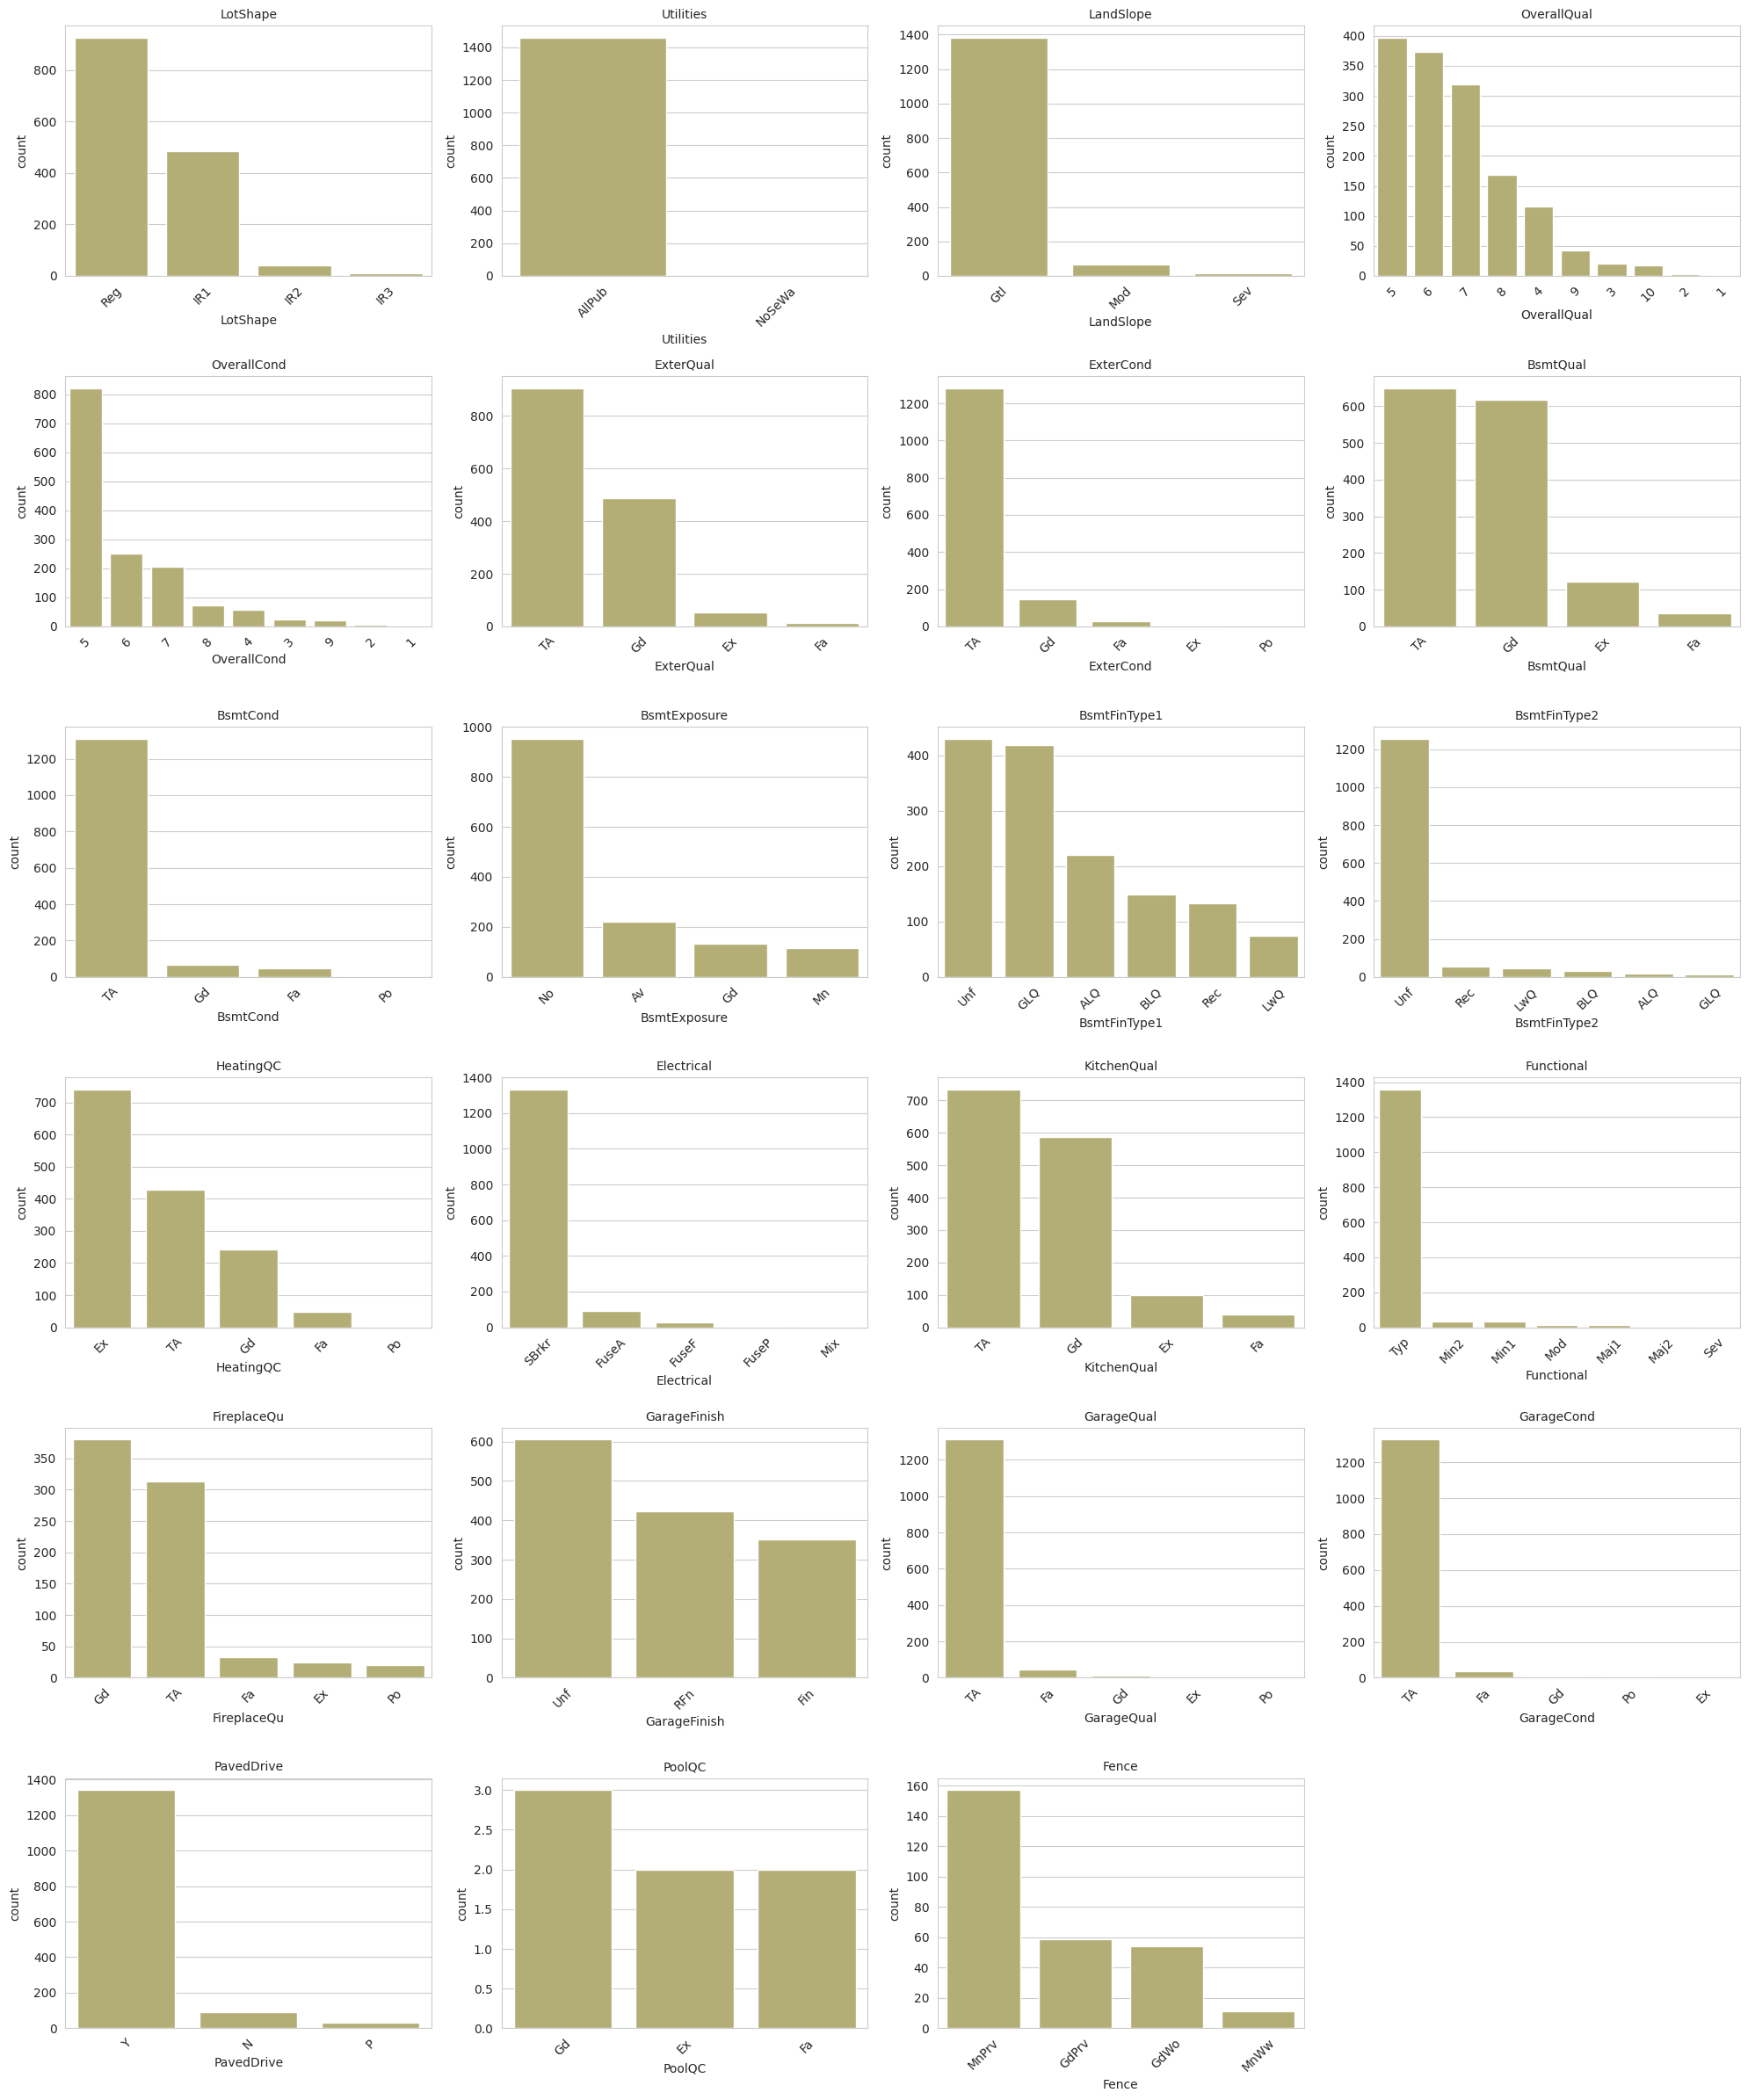

In [88]:
ord_available = [c for c in ordinal_vars if c in train.columns]

n = len(ord_available)
ncols = 4
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(ord_available):
    order = train[col].value_counts().index
    sns.countplot(x=train[col], order=order, ax=axes[i], color='darkkhaki')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## 6. Phân tích các biến định danh

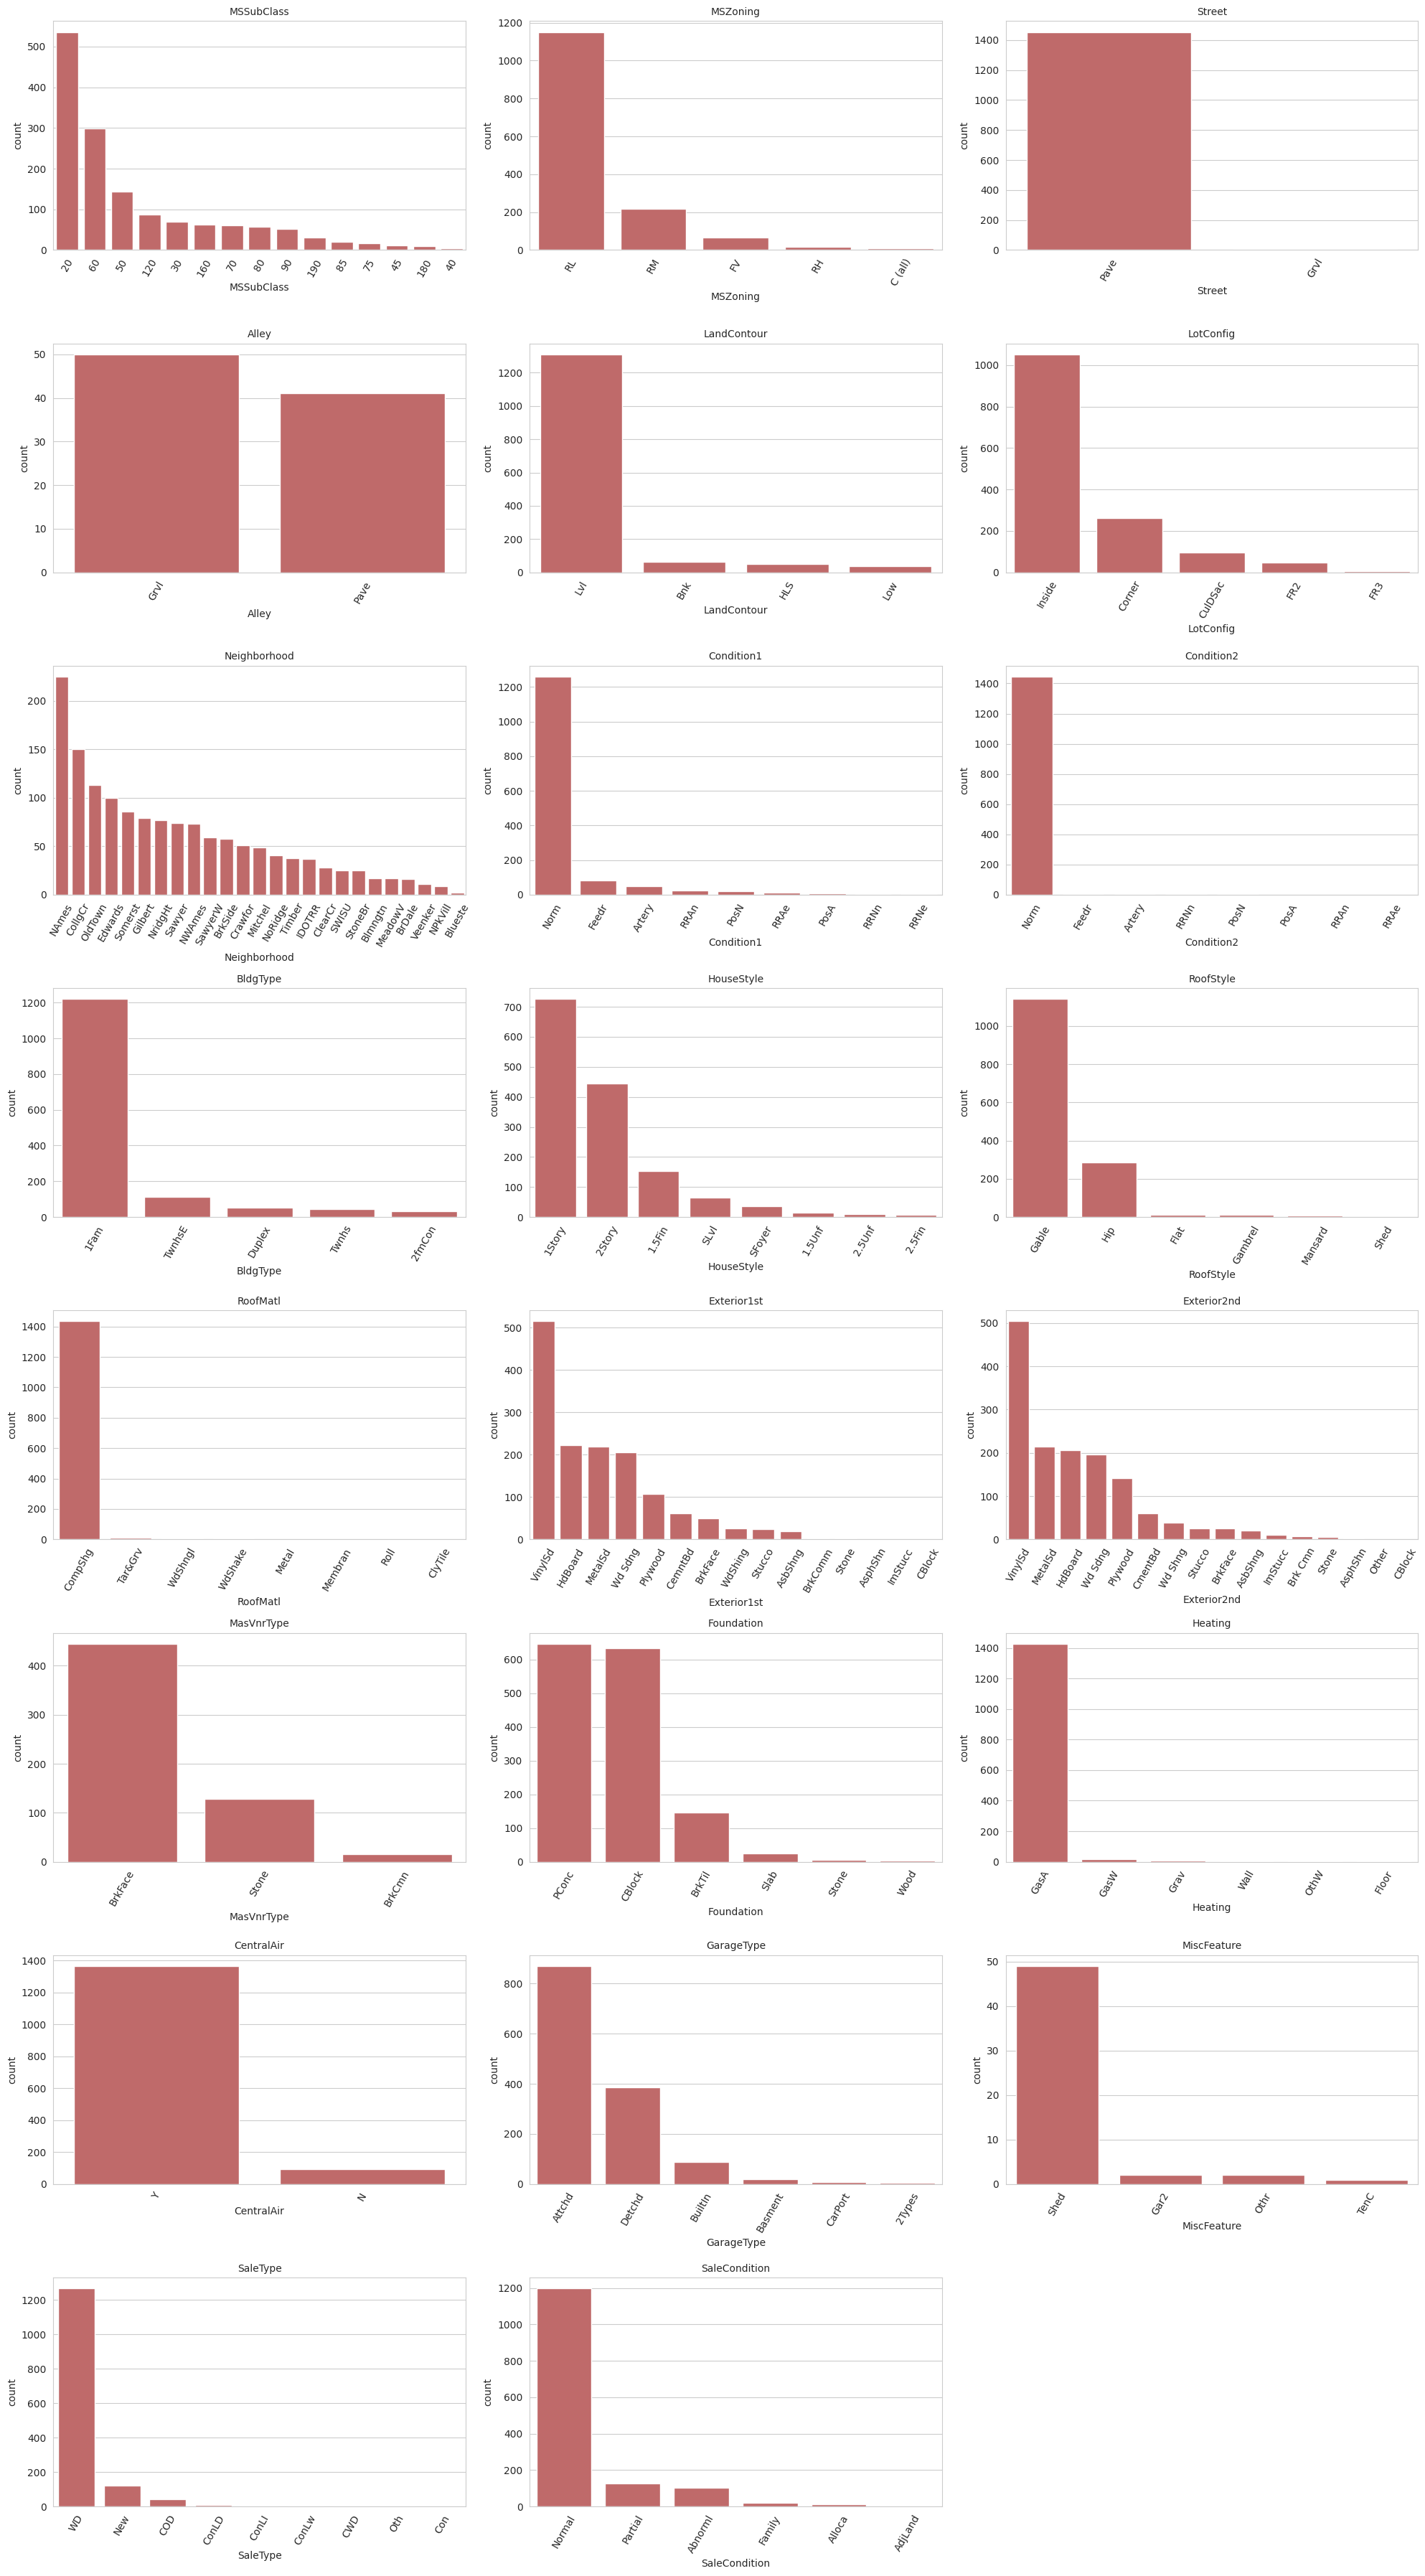

In [89]:
nom_available = [c for c in nominal_vars if c in train.columns]

n = len(nom_available)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.5*nrows))
axes = axes.flatten()

for i, col in enumerate(nom_available):
    order = train[col].value_counts().index
    sns.countplot(x=train[col], order=order, ax=axes[i], color='indianred')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=60)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## 7. Kết luận nhanh

- `SalePrice` lệch phải rõ rệt → nên dùng `log1p(SalePrice)` khi xây dựng mô hình hồi quy.
- Nhiều biến liên tục (`LotArea`, `MiscVal`, `PoolArea`, ...) có phân phối lệch mạnh và nhiều giá trị 0 (do đặc thù: không phải nhà nào cũng có hồ bơi, sân hiên, ...).
- Một số biến rời rạc/thứ bậc có phân phối rất lệch về 1 vài mức (ví dụ `PoolQC`, `Utilities`, `Street` gần như hằng số) → cần cân nhắc loại bỏ hoặc gộp nhóm khi mô hình hóa.
- Biến định danh `Neighborhood` có nhiều mức (28 khu vực như paper đã đề cập) và phân bố tần suất không đều.

→ Các quan sát này sẽ được khai thác tiếp ở notebook `03_Phan_Tich_Da_Bien.ipynb` (mối quan hệ với `SalePrice`) và notebook `04` / `05` (giá trị thiếu và ngoại lệ).

#  PHẦN 3: PHÂN TÍCH ĐA BIẾN 

# Phân tích đa biến (Multivariate Analysis)
Notebook này khảo sát **mối quan hệ giữa các biến với nhau và với biến mục tiêu `SalePrice`**:
- Ma trận tương quan (correlation heatmap) giữa các biến số và `SalePrice`.
- Top các biến liên quan mạnh nhất đến `SalePrice`.
- Scatter matrix / pairplot cho nhóm biến tương quan cao.
- Quan hệ giữa biến định danh/thứ bậc và `SalePrice` (boxplot theo nhóm).
- Kiểm tra đa cộng tuyến (multicollinearity) bằng VIF.
- Tái hiện lại hình 4, 5, 7 trong paper De Cock (2011): `SalePrice` vs `TotalSF`, mô hình hồi quy đa biến mẫu, và `SalePrice` vs diện tích theo `SaleCondition`.

## 1. Import thư viện & nạp dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

import os

def find_data_dir():
    # Tự động tìm thư mục chứa train.csv/test.csv: chạy được cả local lẫn Kaggle Notebook.
    candidates = [
        "./",
        "../input/house-prices-advanced-regression-techniques/",
        "/kaggle/input/competitions/house-prices-advanced-regression-techniques/",
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "train.csv")):
            return c

    raise FileNotFoundError(
        "Không tìm thấy train.csv."
    )

DATA_DIR = find_data_dir()
print("Đang dùng DATA_DIR =", DATA_DIR)

train = pd.read_csv(DATA_DIR + "train.csv")
print("Kích thước train:", train.shape)


Đang dùng DATA_DIR = /kaggle/input/competitions/house-prices-advanced-regression-techniques/
Kích thước train: (1460, 81)


## 2. Ma trận tương quan giữa các biến số

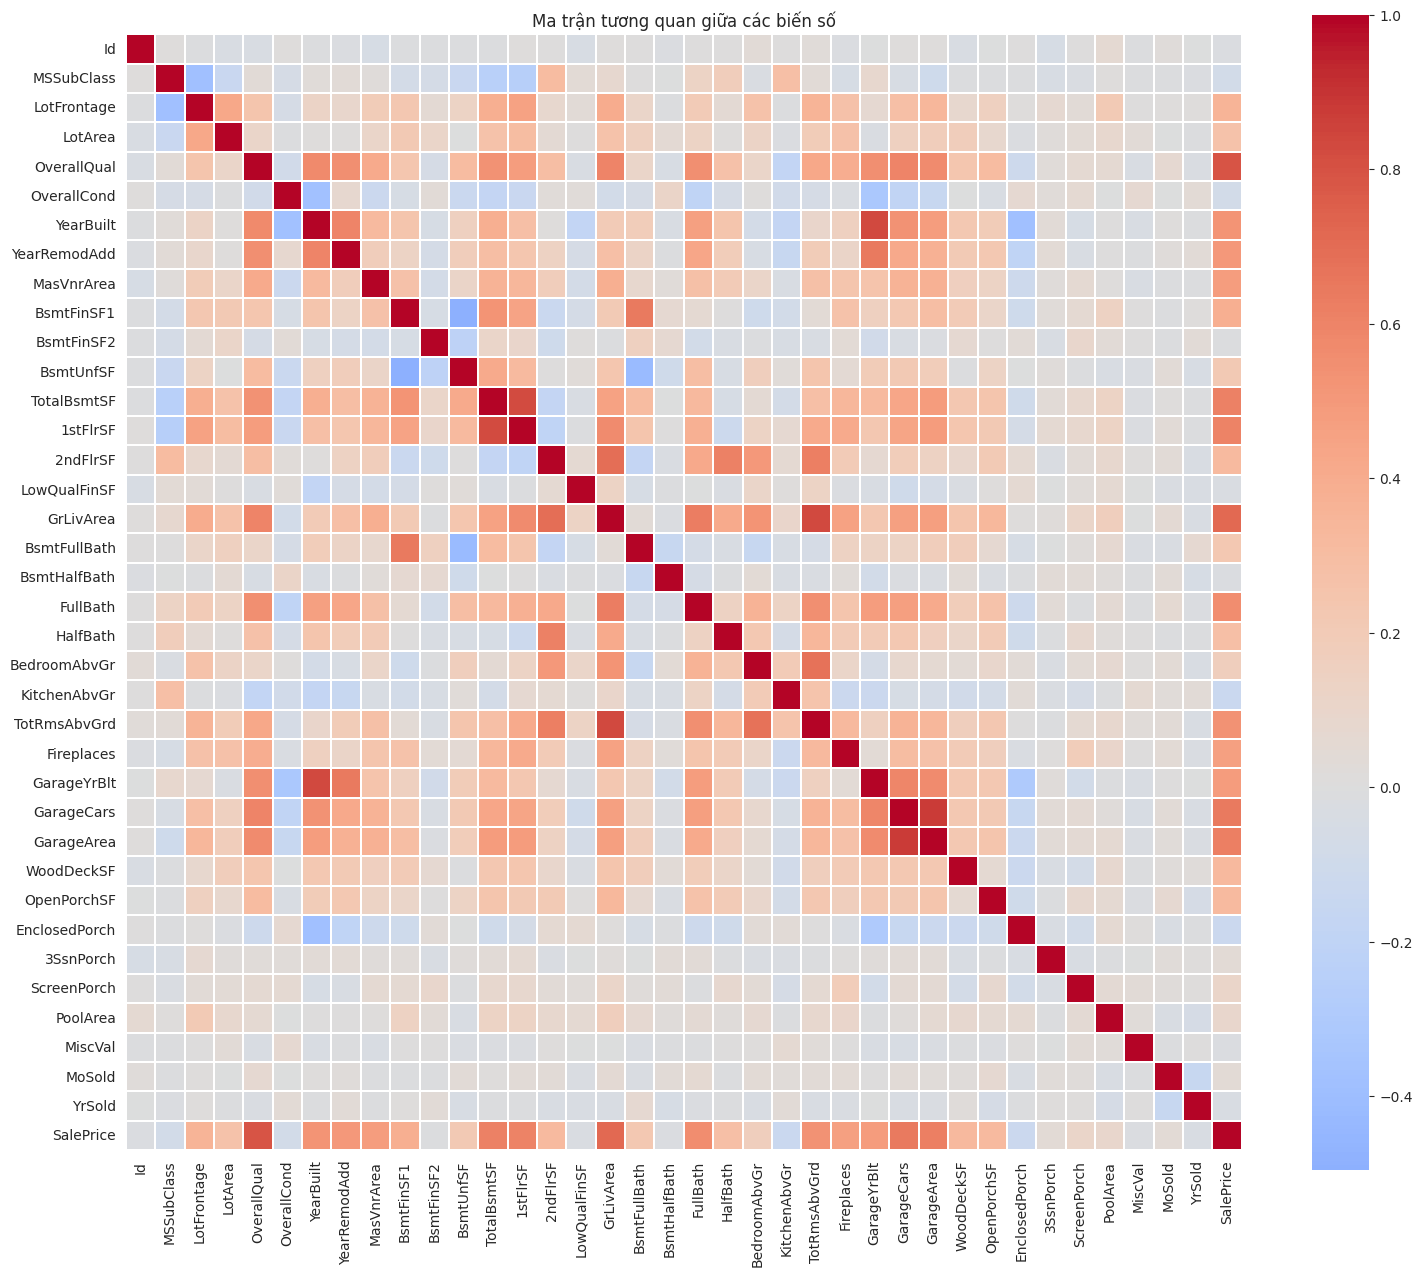

In [91]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[numeric_cols].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, square=True)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()


### 2.1. Top 15 biến tương quan mạnh nhất với `SalePrice`

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


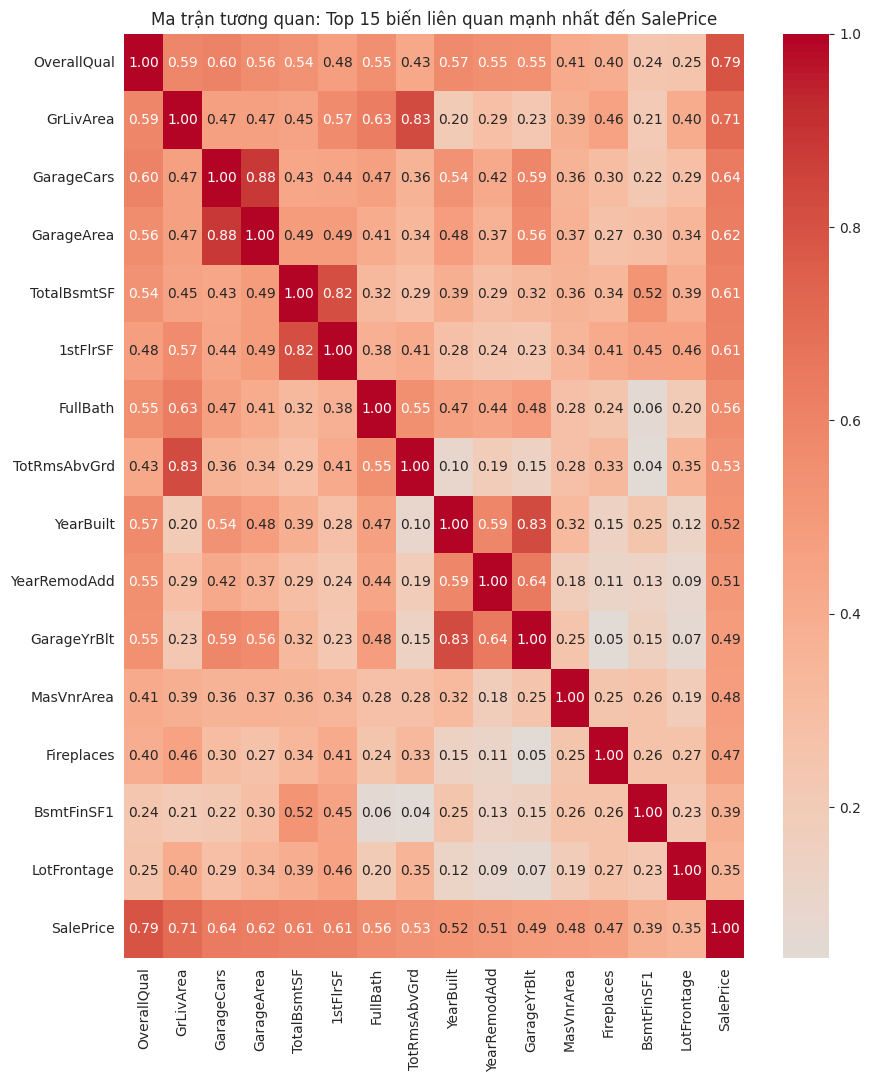

In [92]:
top_corr = corr['SalePrice'].abs().sort_values(ascending=False)
top_corr_features = top_corr.index[1:16]  # bỏ chính SalePrice

print(corr['SalePrice'].loc[top_corr_features].sort_values(ascending=False))

plt.figure(figsize=(10, 12))
sns.heatmap(train[list(top_corr_features) + ['SalePrice']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Ma trận tương quan: Top 15 biến liên quan mạnh nhất đến SalePrice')
plt.show()


**Nhận xét:** Đúng như paper đề cập ("many of the continuous variables in this data set are linearly related to the sales price"),
các biến diện tích (`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`) có tương quan dương mạnh nhất với `SalePrice`.

## 3. Scatter/Pairplot cho nhóm biến tương quan cao nhất

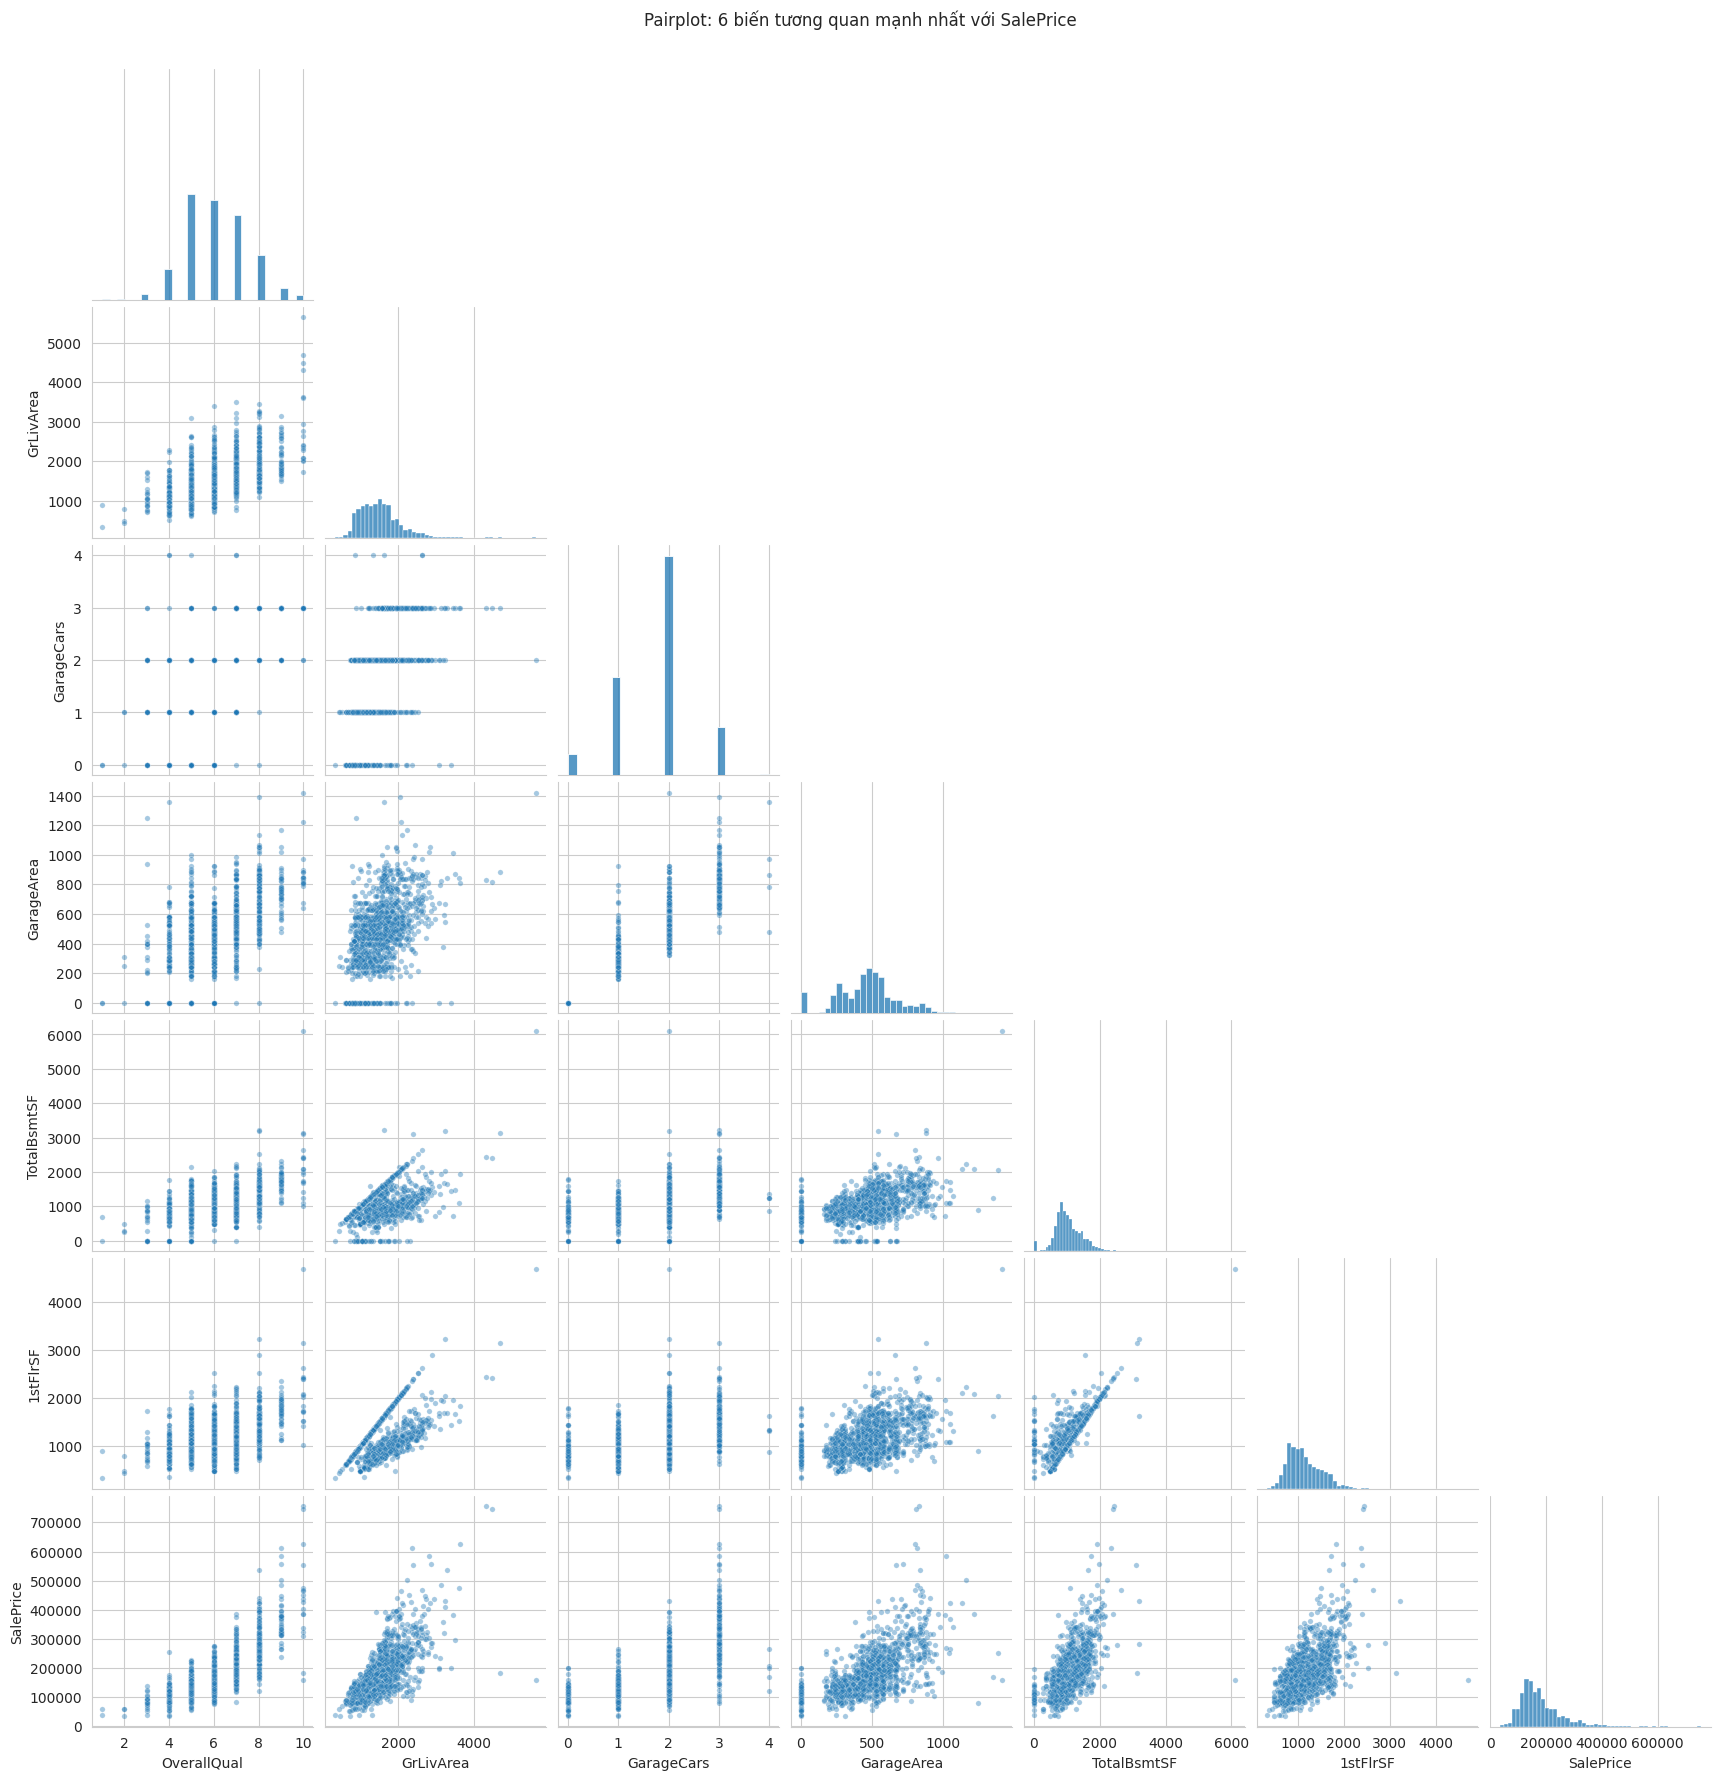

In [93]:
top6 = top_corr_features[:6].tolist()
sns.pairplot(train[top6 + ['SalePrice']], corner=True, plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot: 6 biến tương quan mạnh nhất với SalePrice', y=1.02)
plt.show()


## 4. Tái hiện Hình 4 (paper): `SalePrice` vs Tổng diện tích (`TotalSF`)

Paper định nghĩa `TotSF = TOTAL BSMT SF + GR LIV AREA` và cho thấy quan hệ gần tuyến tính (R² ≈ 54.8%) kèm dấu hiệu cong nhẹ (curvature).

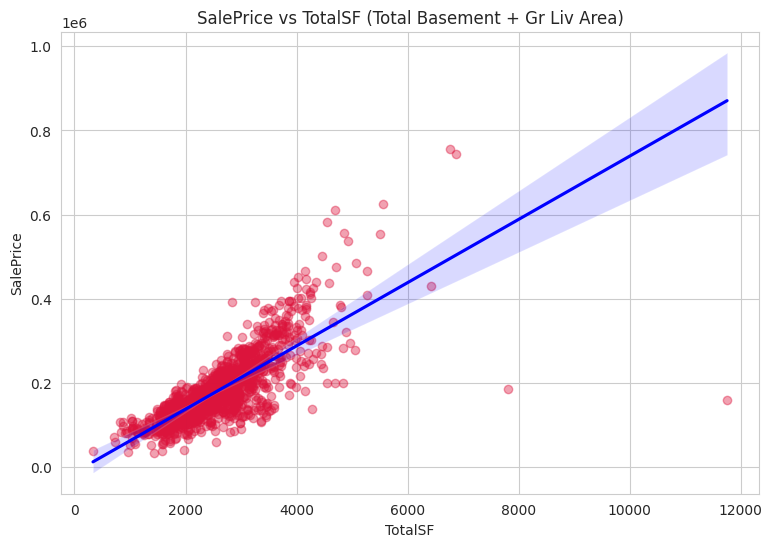

Hệ số tương quan Pearson r = 0.779  (R^2 = 60.7%)


In [94]:
train['TotalSF'] = train['TotalBsmtSF'] + train['GrLivArea']

plt.figure(figsize=(9, 6))
sns.regplot(x='TotalSF', y='SalePrice', data=train,
            scatter_kws={'alpha': 0.4, 'color': 'crimson'}, line_kws={'color': 'blue'})
plt.title('SalePrice vs TotalSF (Total Basement + Gr Liv Area)')
plt.show()

from scipy.stats import pearsonr
r, p = pearsonr(train['TotalSF'], train['SalePrice'])
print(f"Hệ số tương quan Pearson r = {r:.3f}  (R^2 = {r**2*100:.1f}%)")


## 5. Tái hiện Hình 5 (paper): Mô hình hồi quy đa biến mẫu

Paper minh họa một mô hình đa biến đơn giản:
`SalePrice = 7851 + 1.72 Lot Area + 41.2 Total Bsmt SF + 40.8 Gr Liv Area + 20952 Garage Cars + 8379 FireYN`

Ta tái hiện bằng OLS (statsmodels) trên tập Kaggle để so sánh hệ số & R².

In [95]:
import statsmodels.api as sm

df_model = train.copy()
df_model['FireYN'] = (df_model['Fireplaces'] > 0).astype(int)
df_model['TotalBsmtSF'] = df_model['TotalBsmtSF'].fillna(0)
df_model['GarageCars'] = df_model['GarageCars'].fillna(0)

X = df_model[['LotArea', 'TotalBsmtSF', 'GrLivArea', 'GarageCars', 'FireYN']]
X = sm.add_constant(X)
y = df_model['SalePrice']

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     648.7
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:49:14   Log-Likelihood:                -17688.
No. Observations:                1460   AIC:                         3.539e+04
Df Residuals:                    1454   BIC:                         3.542e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2.749e+04   3992.666     -6.886      

## 6. Quan hệ giữa biến thứ bậc/rời rạc và `SalePrice` 

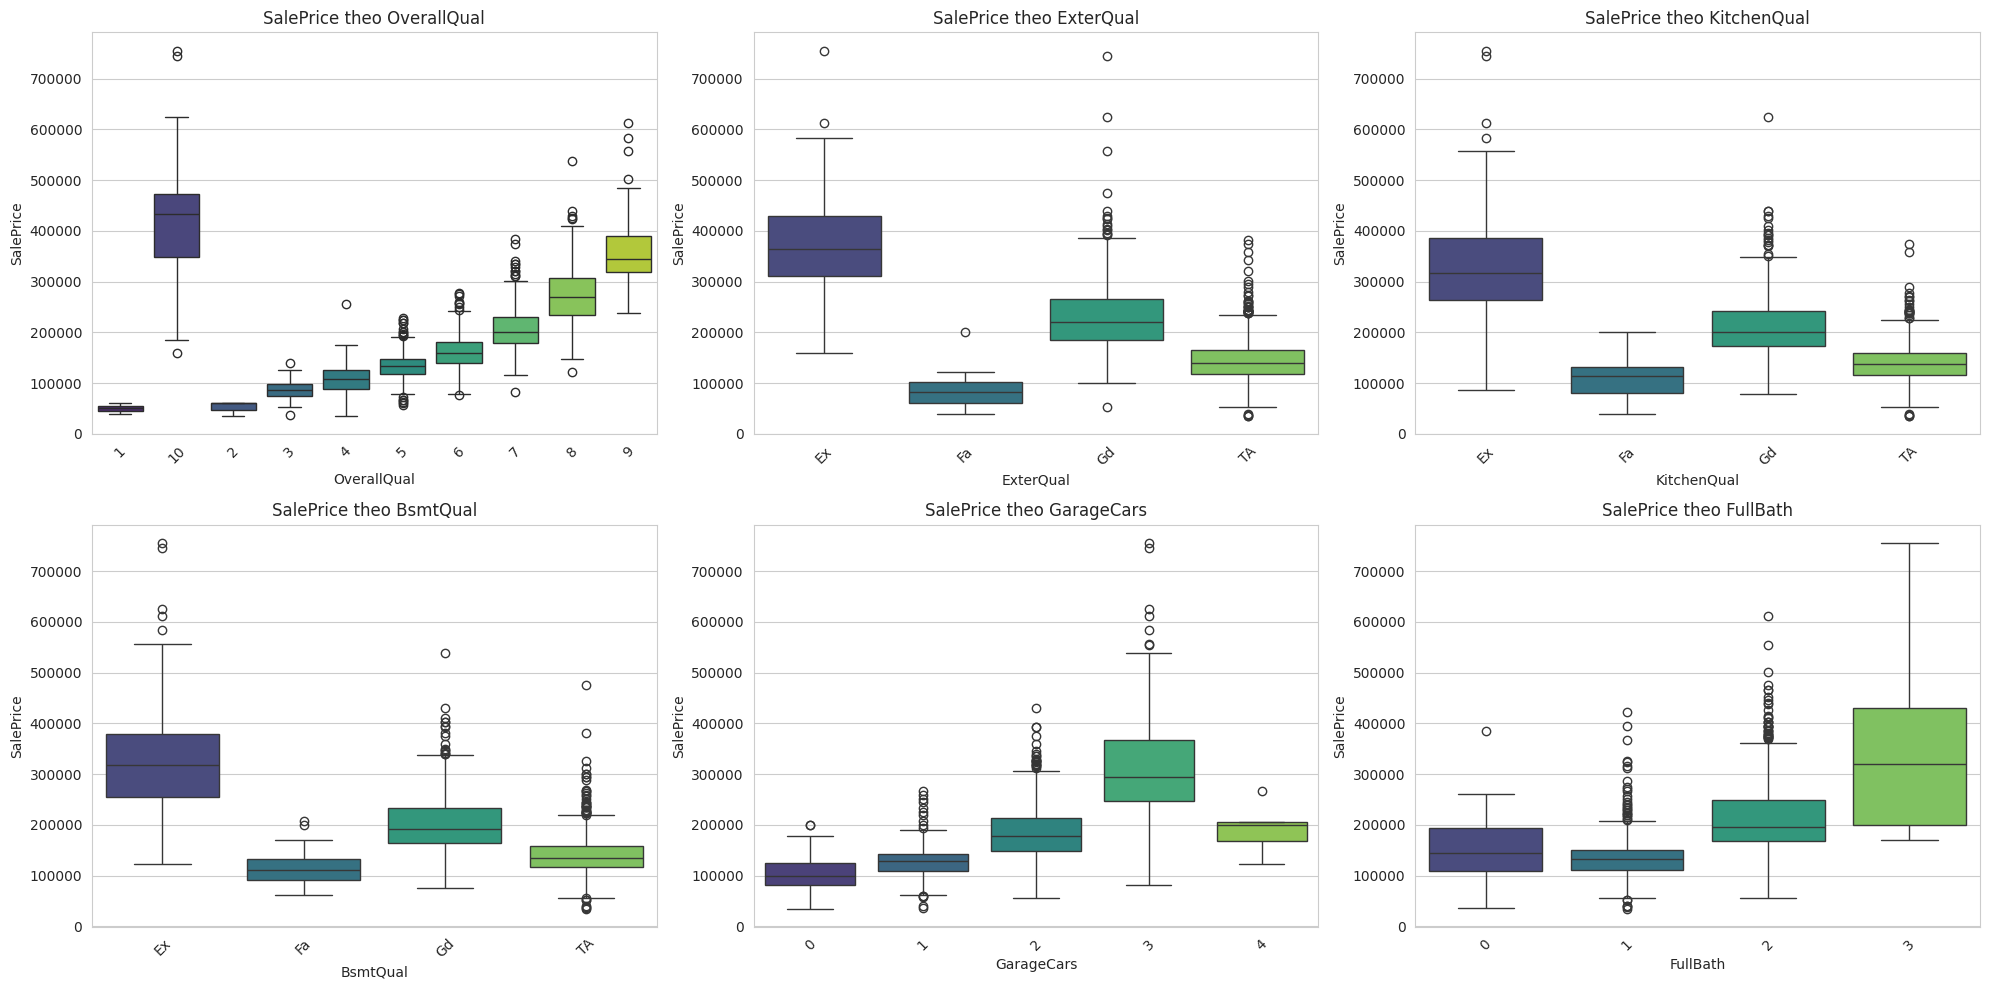

In [96]:
ordinal_key = ['OverallQual', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageCars', 'FullBath']
ordinal_key = [c for c in ordinal_key if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(ordinal_key):
    order = sorted(train[col].dropna().unique(), key=lambda x: str(x))
    sns.boxplot(x=col, y='SalePrice', data=train, order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'SalePrice theo {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 7. Quan hệ giữa biến định danh và `SalePrice`: `Neighborhood`

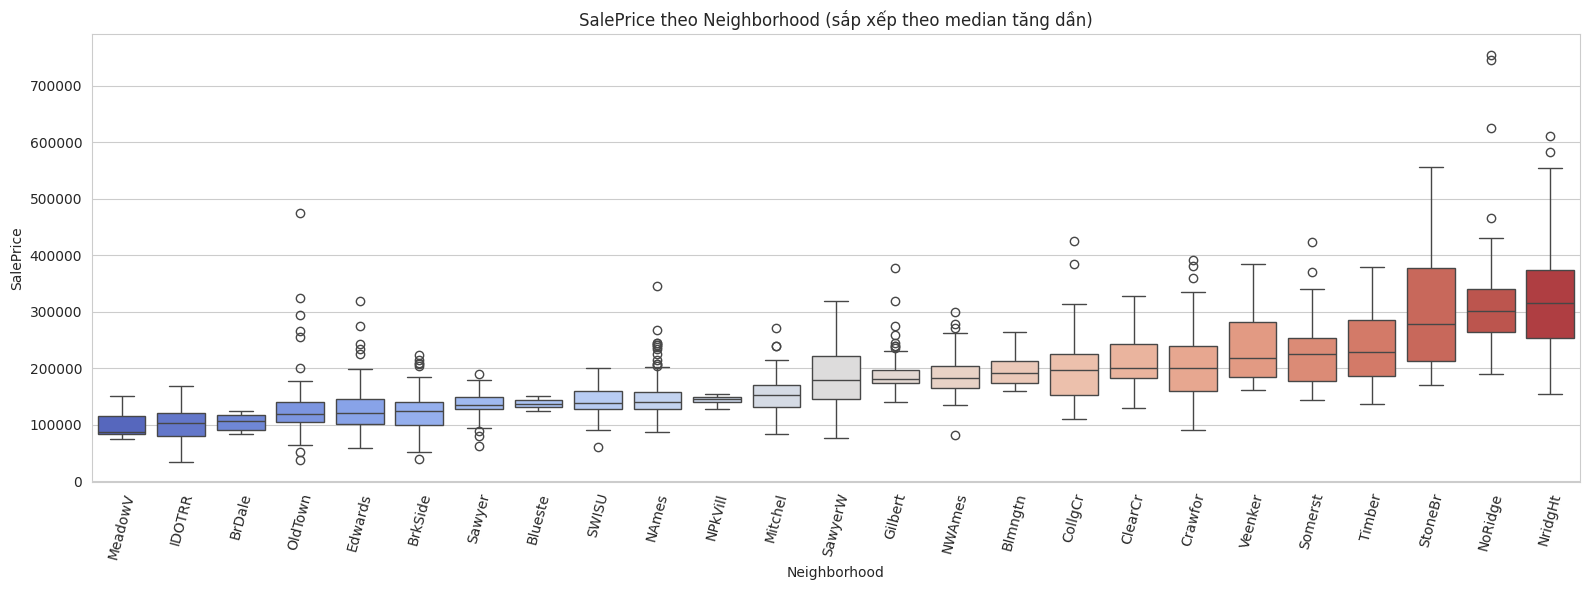

In [97]:
plt.figure(figsize=(16, 6))
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(x='Neighborhood', y='SalePrice', data=train, order=order, palette='coolwarm')
plt.xticks(rotation=75)
plt.title('SalePrice theo Neighborhood (sắp xếp theo median tăng dần)')
plt.tight_layout()
plt.show()


## 8. Tái hiện Hình 7 (paper): `SalePrice` vs Diện tích theo `SaleCondition`

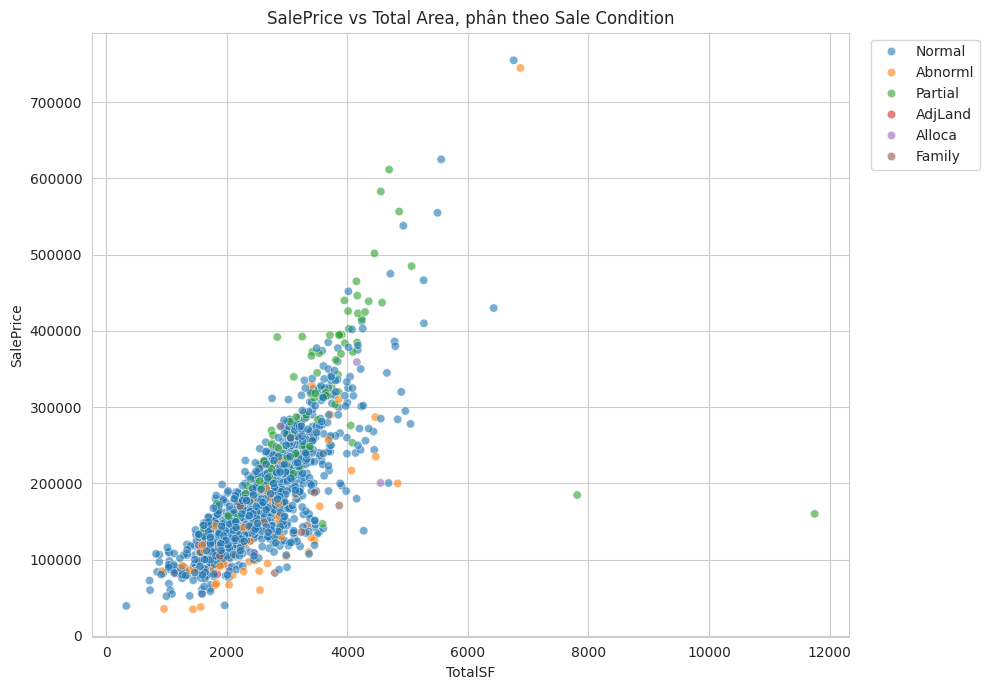

In [98]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='TotalSF', y='SalePrice', hue='SaleCondition', data=train,
                 alpha=0.6, palette='tab10')
plt.title('SalePrice vs Total Area, phân theo Sale Condition')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Nhận xét (đối chiếu paper):** nhà `Partial` (nhà mới, bán một phần) thường có giá cao hơn với cùng diện tích, trong khi nhà `Abnormal` (bán gấp/siết nợ) thường có giá thấp hơn — đúng như mô tả trong paper.

## 9. Kiểm tra đa cộng tuyến (Multicollinearity) bằng VIF

In [99]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ['LotArea', 'TotalBsmtSF', 'GrLivArea', 'GarageCars', 'GarageArea',
            'OverallQual', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd']
vif_cols = [c for c in vif_cols if c in train.columns]

X_vif = train[vif_cols].fillna(0)
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values('VIF', ascending=False)


,feature,VIF
0,const,35.199726
4,GarageCars,5.101252
5,GarageArea,4.930881
3,GrLivArea,4.866104
7,1stFlrSF,3.685316
2,TotalBsmtSF,3.521118
9,TotRmsAbvGrd,3.328363
6,OverallQual,2.329988
8,FullBath,1.898689
1,LotArea,1.138372


**Nhận xét:** VIF > 5–10 cho thấy dấu hiệu đa cộng tuyến. `GarageCars` và `GarageArea`, hay `GrLivArea` và `TotRmsAbvGrd`/`1stFlrSF` thường tương quan cao với nhau — cần cân nhắc loại bớt biến trùng lặp thông tin khi xây MODEL1 (giới hạn biến, không cho tương tác) như paper yêu cầu.

## 10. Kết luận nhanh

- `OverallQual`, `GrLivArea`, `GarageCars/GarageArea`, `TotalBsmtSF`, `1stFlrSF` là các biến có quan hệ tuyến tính mạnh nhất với `SalePrice` — ứng viên hàng đầu cho MODEL1 (≥6 biến, R² ≥ 73% theo yêu cầu paper).
- `TotalSF` (tổng diện tích) giải thích ~55% phương sai `SalePrice` chỉ với 1 biến, khớp với Hình 4 trong paper.
- `Neighborhood` và `SaleCondition` là các biến định danh có ảnh hưởng rõ rệt đến giá bán → nên đưa vào mô hình dưới dạng biến giả (dummy).
- Một số biến diện tích có đa cộng tuyến cao (VIF lớn) → cần chọn lọc khi xây MODEL1 (không dùng đồng thời các biến đo cùng một khái niệm).

#  PHẦN 4: GIÁ TRỊ THIẾU & MẪU BẤT THƯỜNG 

# Xác định giá trị thiếu và mẫu bất thường
Notebook này xử lý:
- Thống kê giá trị thiếu (missing values) theo từng cột.
- Phân biệt 2 loại "thiếu": **NA có ý nghĩa** (ví dụ "không có hồ bơi", "không có tầng hầm") vs **thiếu thật sự** (dữ liệu bị mất, cần impute).
- Kiểm tra dòng trùng lặp (duplicate rows).
- Kiểm tra mẫu bất thường / không nhất quán logic (ví dụ: có tầng hầm nhưng diện tích tầng hầm = 0; năm cải tạo trước năm xây dựng, v.v.).

## 1. Import thư viện & nạp dữ liệu

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

import os

def find_data_dir():
    # Tự động tìm thư mục chứa train.csv/test.csv: chạy được cả local lẫn Kaggle Notebook.
    candidates = [
        "./",
        "../input/house-prices-advanced-regression-techniques/",
        "/kaggle/input/competitions/house-prices-advanced-regression-techniques/",
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "train.csv")):
            return c
    raise FileNotFoundError(
        "Không tìm thấy train.csv. "
        
    )

DATA_DIR = find_data_dir()
print("Đang dùng DATA_DIR =", DATA_DIR)

train = pd.read_csv(DATA_DIR + "train.csv")
test = pd.read_csv(DATA_DIR + "test.csv")

print("train:", train.shape, "| test:", test.shape)


Đang dùng DATA_DIR = /kaggle/input/competitions/house-prices-advanced-regression-techniques/
train: (1460, 81) | test: (1459, 80)


## 2. Thống kê giá trị thiếu theo cột

In [101]:
def missing_report(df, name):
    n = df.isnull().sum()
    pct = 100 * n / len(df)
    report = pd.DataFrame({'n_missing': n, 'pct_missing': pct})
    report = report[report['n_missing'] > 0].sort_values('pct_missing', ascending=False)
    print(f"--- {name}: {len(report)} cột có giá trị thiếu ---")
    return report

train_missing = missing_report(train, "train")
train_missing


--- train: 19 cột có giá trị thiếu ---


,n_missing,pct_missing
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


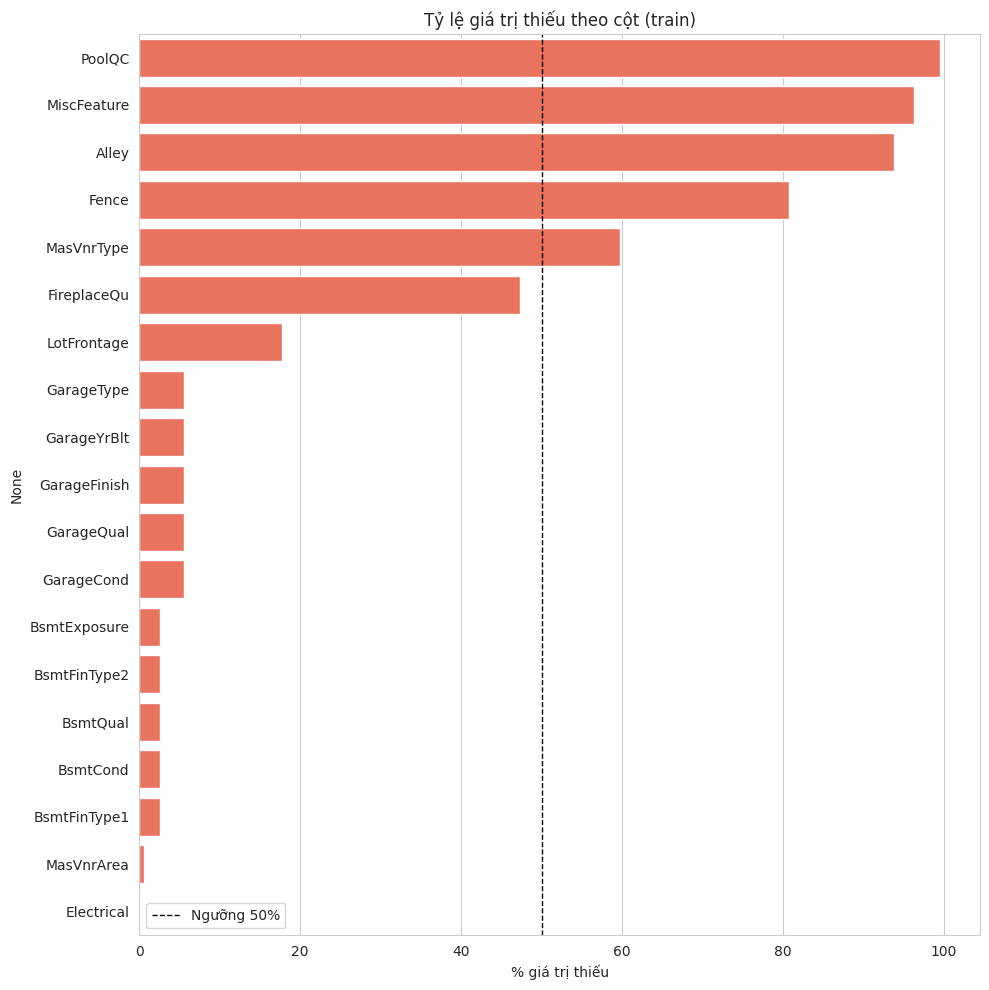

In [102]:
plt.figure(figsize=(10, 10))
sns.barplot(x=train_missing['pct_missing'], y=train_missing.index, color='tomato')
plt.xlabel('% giá trị thiếu')
plt.title('Tỷ lệ giá trị thiếu theo cột (train)')
plt.axvline(50, color='black', linestyle='--', linewidth=1, label='Ngưỡng 50%')
plt.legend()
plt.tight_layout()
plt.show()


## 3. Phân biệt "NA có ý nghĩa" vs "thiếu thật sự"

Theo tài liệu `DataDocumentation.txt` đi kèm bộ dữ liệu Ames, với nhiều biến chất lượng/hạng mục, giá trị `NA` **không phải là dữ liệu bị mất**
mà mang ý nghĩa **"không có hạng mục đó"**. Ví dụ:
- `PoolQC = NA` → nhà không có hồ bơi (khớp với `PoolArea = 0`)
- `Alley = NA` → không có lối đi (alley access)
- `FireplaceQu = NA` → không có lò sưởi (khớp với `Fireplaces = 0`)
- `Garage*  = NA` → không có ga-ra
- `Bsmt* = NA` → không có tầng hầm
- `Fence = NA` → không có hàng rào
- `MiscFeature = NA` → không có hạng mục đặc biệt khác

Ngược lại, các biến sau nếu thiếu thì **thực sự là dữ liệu bị thiếu** cần suy luận/impute:
- `LotFrontage` (chiều dài mặt tiền — có thể suy ra theo trung vị của `Neighborhood`)
- `Electrical` (hệ thống điện — chỉ thiếu 1 dòng, có thể điền bằng mode)
- `MasVnrType`, `MasVnrArea` (ốp tường ngoài — số ít trường hợp thật sự thiếu)
- `GarageYrBlt` (nếu không có ga-ra thì đây là NA có ý nghĩa, không phải thiếu thật sự)

In [103]:
na_means_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
na_means_none = [c for c in na_means_none if c in train.columns]

truly_missing = [c for c in train_missing.index if c not in na_means_none]

print("Nhóm 'NA có ý nghĩa' (điền = 'None' hoặc 0):")
print(na_means_none)
print()
print("Nhóm 'thiếu thật sự' (cần impute cẩn thận):")
print(truly_missing)


Nhóm 'NA có ý nghĩa' (điền = 'None' hoặc 0):
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

Nhóm 'thiếu thật sự' (cần impute cẩn thận):
['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'Electrical']


In [104]:
# Kiểm chứng: PoolQC NA có khớp với PoolArea = 0 không?
check = train[['PoolArea', 'PoolQC']].copy()
mismatch = check[(check['PoolQC'].isna()) & (check['PoolArea'] > 0)]
print(f"Số dòng PoolQC=NA nhưng PoolArea>0 (bất thường nếu có): {len(mismatch)}")
mismatch


Số dòng PoolQC=NA nhưng PoolArea>0 (bất thường nếu có): 0


,PoolArea,PoolQC


In [105]:
# Kiểm chứng tương tự cho Garage: GarageType NA có khớp GarageArea = 0 không?
check_garage = train[['GarageArea', 'GarageType', 'GarageCars']].copy()
mismatch_g = check_garage[(check_garage['GarageType'].isna()) & (check_garage['GarageArea'] > 0)]
print(f"Số dòng GarageType=NA nhưng GarageArea>0 (bất thường nếu có): {len(mismatch_g)}")
mismatch_g


Số dòng GarageType=NA nhưng GarageArea>0 (bất thường nếu có): 0


,GarageArea,GarageType,GarageCars


In [106]:
# Kiểm chứng cho Basement: BsmtQual NA có khớp TotalBsmtSF = 0 không?
check_bsmt = train[['TotalBsmtSF', 'BsmtQual']].copy()
mismatch_b = check_bsmt[(check_bsmt['BsmtQual'].isna()) & (check_bsmt['TotalBsmtSF'] > 0)]
print(f"Số dòng BsmtQual=NA nhưng TotalBsmtSF>0 (bất thường nếu có): {len(mismatch_b)}")
mismatch_b


Số dòng BsmtQual=NA nhưng TotalBsmtSF>0 (bất thường nếu có): 0


,TotalBsmtSF,BsmtQual


### 3.1. Đề xuất xử lý (không thực thi impute ở đây — chỉ đề xuất cho notebook mô hình hóa)

In [107]:
suggestion = pd.DataFrame({
    'column': train_missing.index,
    'pct_missing': train_missing['pct_missing'].round(2),
    'de_xuat_xu_ly': [
        'Điền "None"/0 (không có hạng mục)' if c in na_means_none
        else ('Xóa cột (thiếu > 90%)' if train_missing.loc[c, 'pct_missing'] > 90
              else 'Impute theo Neighborhood/median hoặc mode')
        for c in train_missing.index
    ]
})
suggestion


,column,pct_missing,de_xuat_xu_ly
PoolQC,PoolQC,99.52,"Điền ""None""/0 (không có hạng mục)"
MiscFeature,MiscFeature,96.30,"Điền ""None""/0 (không có hạng mục)"
Alley,Alley,93.77,"Điền ""None""/0 (không có hạng mục)"
Fence,Fence,80.75,"Điền ""None""/0 (không có hạng mục)"
MasVnrType,MasVnrType,59.73,"Điền ""None""/0 (không có hạng mục)"
FireplaceQu,FireplaceQu,47.26,"Điền ""None""/0 (không có hạng mục)"
LotFrontage,LotFrontage,17.74,Impute theo Neighborhood/median hoặc mode
GarageType,GarageType,5.55,"Điền ""None""/0 (không có hạng mục)"
GarageYrBlt,GarageYrBlt,5.55,Impute theo Neighborhood/median hoặc mode
GarageFinish,GarageFinish,5.55,"Điền ""None""/0 (không có hạng mục)"


## 4. Kiểm tra dòng trùng lặp 

In [108]:
dup_full = train.drop(columns=['Id']).duplicated().sum()
dup_id = train['Id'].duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn (bỏ qua Id): {dup_full}")
print(f"Số Id bị trùng: {dup_id}")


Số dòng trùng lặp hoàn toàn (bỏ qua Id): 0
Số Id bị trùng: 0


## 5. Phát hiện mẫu bất thường — kiểm tra logic dữ liệu

Áp dụng một số quy tắc logic đơn giản để phát hiện các dòng có khả năng bị lỗi nhập liệu hoặc bất thường thật sự.

In [109]:
anomalies = {}

# (a) Năm cải tạo (YearRemodAdd) < Năm xây dựng (YearBuilt)
anomalies['RemodBeforeBuilt'] = train[train['YearRemodAdd'] < train['YearBuilt']]

# (b) Năm bán (YrSold) < Năm xây dựng (YearBuilt)
anomalies['SoldBeforeBuilt'] = train[train['YrSold'] < train['YearBuilt']]

# (c) GarageYrBlt lớn hơn năm bán (garage xây "trong tương lai")
anomalies['GarageAfterSold'] = train[train['GarageYrBlt'] > train['YrSold']]

# (d) Tổng số phòng trên mặt đất (TotRmsAbvGrd) nhỏ hơn số phòng ngủ + phòng bếp
anomalies['RoomsLessThanBedKitchen'] = train[
    train['TotRmsAbvGrd'] < (train['BedroomAbvGr'] + train['KitchenAbvGr'])
]

# (e) Có tầng hầm hoàn thiện (BsmtFinSF1/2 > 0) nhưng TotalBsmtSF = 0
anomalies['BsmtFinButNoTotal'] = train[
    ((train['BsmtFinSF1'] > 0) | (train['BsmtFinSF2'] > 0)) & (train['TotalBsmtSF'] == 0)
]

for name, df_a in anomalies.items():
    print(f"{name}: {len(df_a)} dòng bất thường")


RemodBeforeBuilt: 0 dòng bất thường
SoldBeforeBuilt: 0 dòng bất thường
GarageAfterSold: 0 dòng bất thường
RoomsLessThanBedKitchen: 0 dòng bất thường
BsmtFinButNoTotal: 0 dòng bất thường


In [110]:
anomalies['RemodBeforeBuilt'][['Id', 'YearBuilt', 'YearRemodAdd']]


,Id,YearBuilt,YearRemodAdd


In [111]:
anomalies['GarageAfterSold'][['Id', 'YrSold', 'GarageYrBlt']]


,Id,YrSold,GarageYrBlt


**Nhận xét:** `GarageYrBlt` đôi khi bị nhập nhầm (ví dụ giá trị `2207` thay vì `2007`) — đây là lỗi nhập liệu kinh điển của bộ dữ liệu này, cần kiểm tra và sửa/loại bỏ khi tiền xử lý.

In [112]:
# Kiểm tra giá trị GarageYrBlt bất thường (ngoài khoảng hợp lý, ví dụ > 2010 - năm cuối của bộ dữ liệu)
print("Giá trị GarageYrBlt lớn nhất:", train['GarageYrBlt'].max())
train[train['GarageYrBlt'] > 2010][['Id', 'YearBuilt', 'GarageYrBlt', 'YrSold']]


Giá trị GarageYrBlt lớn nhất: 2010.0


,Id,YearBuilt,GarageYrBlt,YrSold


## 6. Kết luận nhanh

- Các cột `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, và nhóm `Garage*`/`Bsmt*` có tỉ lệ "thiếu" rất cao nhưng thực chất là **NA có ý nghĩa** (không có hạng mục đó), **không nên xóa** mà nên điền `"None"`/`0`.
- `LotFrontage`, `MasVnrType/Area`, `Electrical` là các trường hợp **thiếu thật sự**, cần impute cẩn thận (ví dụ theo trung vị nhóm `Neighborhood`).
- Không phát hiện dòng trùng lặp hoàn toàn.
- Phát hiện một số mẫu bất thường về logic thời gian (`GarageYrBlt` có giá trị lỗi như `2207`), cần làm sạch trước khi mô hình hóa.
- Các phát hiện này sẽ được đối chiếu tiếp với phân tích ngoại lệ số học ở notebook `05_Xac_Dinh_Ngoai_Le.ipynb`.

#  PHẦN 5: XÁC ĐỊNH NGOẠI LỆ 

#  Xác định ngoại lệ (Outlier Detection)
Notebook này tập trung phát hiện **ngoại lệ (outliers)** trong bộ dữ liệu Ames Housing, bao gồm:
1. Tái hiện phát hiện kinh điển của chính paper De Cock (2011): 5 quan sát bất thường khi vẽ `SalePrice` vs `GrLivArea` (mục "Potential Pitfalls (Outliers)").
2. Phát hiện ngoại lệ bằng phương pháp IQR (boxplot rule) cho các biến liên tục quan trọng.
3. Phát hiện ngoại lệ bằng Z-score.
4. Phát hiện ngoại lệ đa biến bằng Isolation Forest (góc nhìn machine learning).
5. Đề xuất danh sách quan sát nên loại bỏ trước khi xây mô hình.

## 1. Import thư viện & nạp dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

import os

def find_data_dir():
    # Tự động tìm thư mục chứa train.csv/test.csv: chạy được cả local lẫn Kaggle Notebook.
    candidates = [
        "./",
        "../input/house-prices-advanced-regression-techniques/",
        "/kaggle/input/competitions/house-prices-advanced-regression-techniques/",
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "train.csv")):
            return c
    raise FileNotFoundError(
        "Không tìm thấy train.csv. "
    )

DATA_DIR = find_data_dir()
print("Đang dùng DATA_DIR =", DATA_DIR)

train = pd.read_csv(DATA_DIR + "train.csv")
print("Kích thước train:", train.shape)


Đang dùng DATA_DIR = /kaggle/input/competitions/house-prices-advanced-regression-techniques/
Kích thước train: (1460, 81)


## 2. Tái hiện phát hiện của paper: `SalePrice` vs `GrLivArea`

Trích nguyên văn từ paper (mục "Potential Pitfalls"):
> *"There are five observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will quickly indicate these points)... I would recommend removing any houses with more than 4000 square feet."*

Ta vẽ lại đúng biểu đồ này trên tập Kaggle (`train.csv`, 1460 dòng, tập con của 2930 dòng gốc).

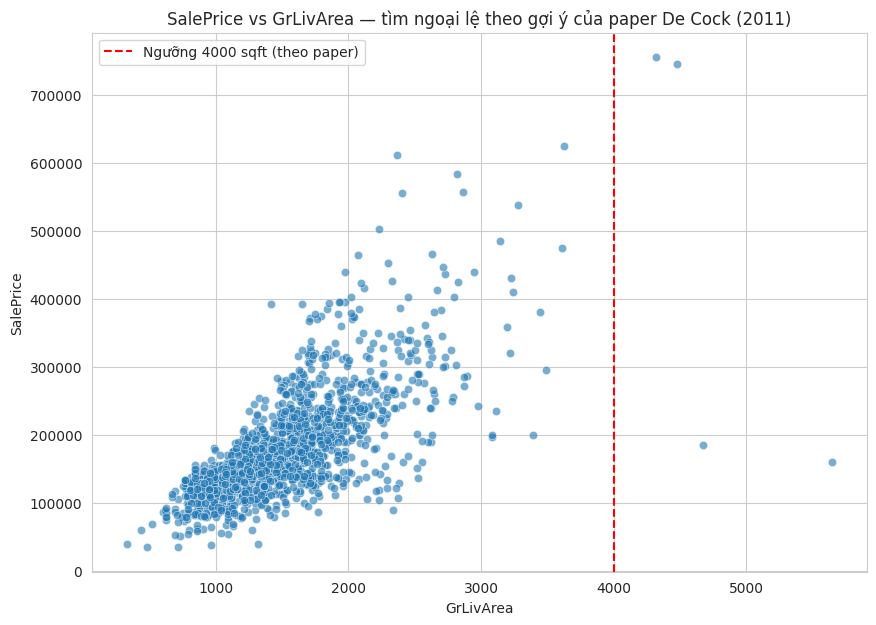

Số quan sát có GrLivArea > 4000 sqft: 4


,Id,GrLivArea,SalePrice,SaleCondition
523,524,4676,184750,Partial
691,692,4316,755000,Normal
1182,1183,4476,745000,Abnorml
1298,1299,5642,160000,Partial


In [114]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, alpha=0.6)
plt.axvline(4000, color='red', linestyle='--', label='Ngưỡng 4000 sqft (theo paper)')
plt.title('SalePrice vs GrLivArea — tìm ngoại lệ theo gợi ý của paper De Cock (2011)')
plt.legend()
plt.show()

outliers_paper = train[train['GrLivArea'] > 4000]
print(f"Số quan sát có GrLivArea > 4000 sqft: {len(outliers_paper)}")
outliers_paper[['Id', 'GrLivArea', 'SalePrice', 'SaleCondition']]


**Nhận xét:** Trong bản Kaggle thường thấy 4 điểm với `GrLivArea > 4000`, trong đó 2 điểm có `SalePrice` **thấp bất thường** so với diện tích cực lớn — đây chính là các quan sát ngoại lệ "kinh điển" mà hầu hết các bài phân tích Kaggle House Prices đều loại bỏ trước khi huấn luyện mô hình.

## 3. Phát hiện ngoại lệ bằng phương pháp IQR (Boxplot Rule)

In [115]:
def iqr_outlier_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

key_continuous = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'SalePrice']
key_continuous = [c for c in key_continuous if c in train.columns]

iqr_summary = []
for col in key_continuous:
    lower, upper = iqr_outlier_bounds(train[col].dropna())
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    iqr_summary.append({'column': col, 'lower_bound': round(lower, 1),
                         'upper_bound': round(upper, 1), 'n_outliers': n_out,
                         'pct_outliers': round(100*n_out/len(train), 2)})

iqr_summary_df = pd.DataFrame(iqr_summary).sort_values('n_outliers', ascending=False)
iqr_summary_df


,column,lower_bound,upper_bound,n_outliers,pct_outliers
1,LotArea,1481.5,17673.5,69,4.73
2,TotalBsmtSF,42.0,2052.0,61,4.18
5,SalePrice,3937.5,340037.5,61,4.18
0,GrLivArea,158.6,2747.6,31,2.12
4,GarageArea,-27.8,938.2,21,1.44
3,1stFlrSF,118.1,2155.1,20,1.37


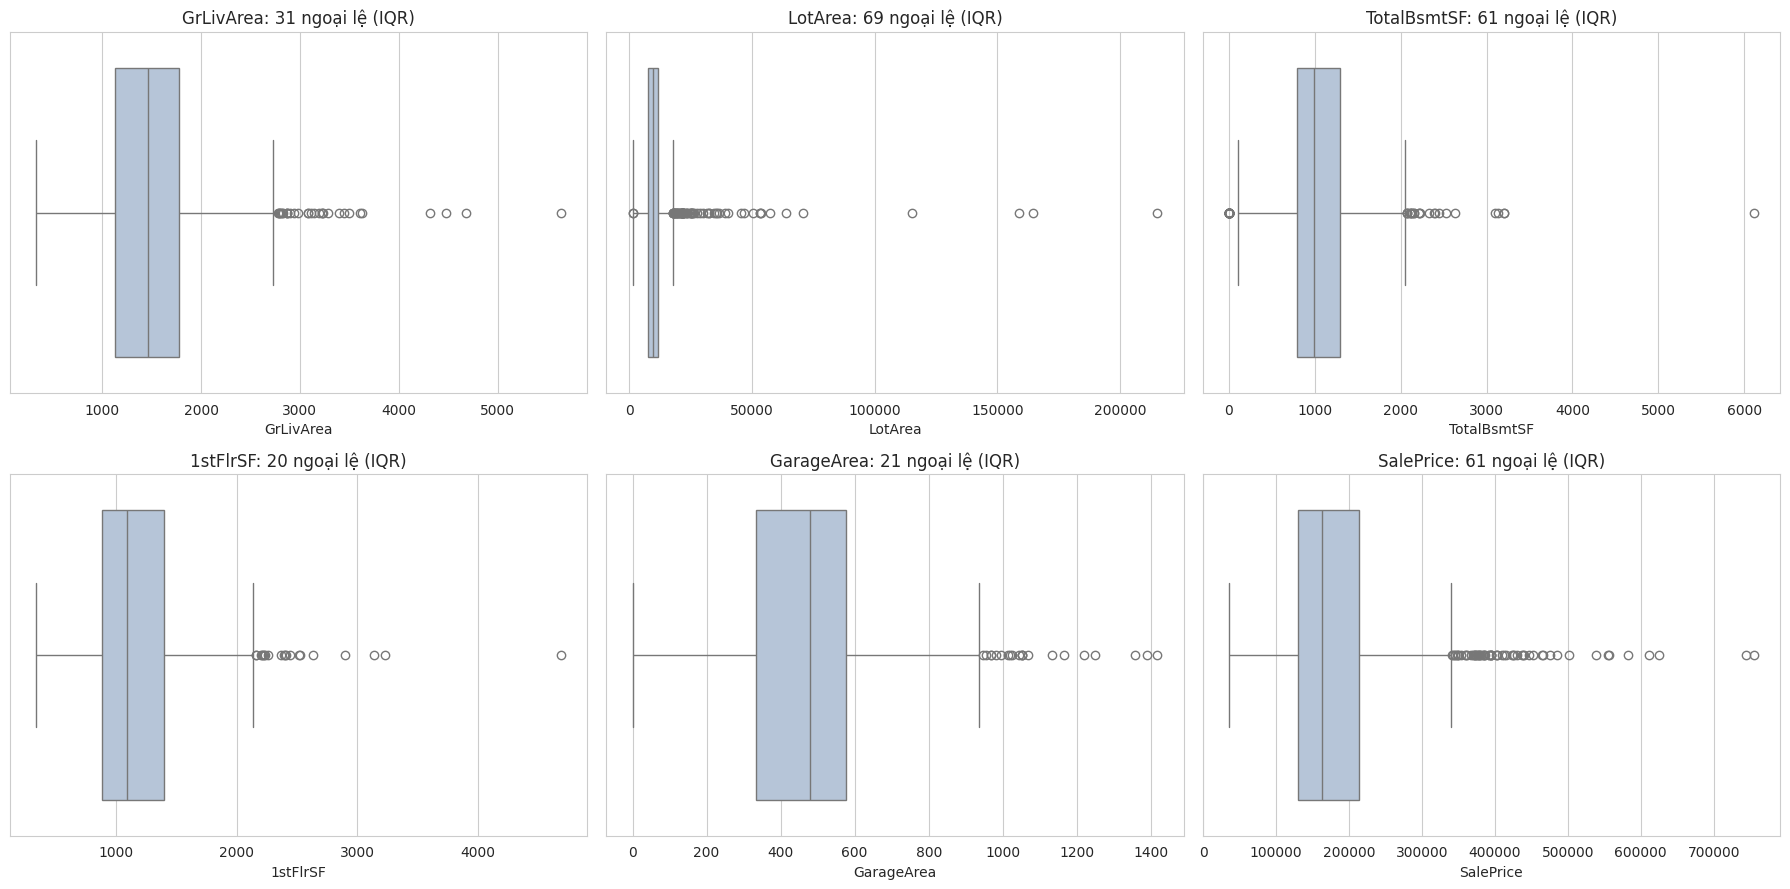

In [116]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(key_continuous):
    sns.boxplot(x=train[col], ax=axes[i], color='lightsteelblue')
    axes[i].set_title(f'{col}: {iqr_summary_df.set_index("column").loc[col, "n_outliers"]} ngoại lệ (IQR)')
plt.tight_layout()
plt.show()


## 4. Phát hiện ngoại lệ bằng Z-score

In [117]:
from scipy import stats

z_summary = []
outlier_ids_zscore = set()
for col in key_continuous:
    valid = train[col].dropna()
    z = np.abs(stats.zscore(valid))
    mask = z > 3
    ids = train.loc[valid.index[mask], 'Id'].tolist()
    outlier_ids_zscore.update(ids)
    z_summary.append({'column': col, 'n_outliers_z>3': mask.sum()})

pd.DataFrame(z_summary)


,column,n_outliers_z>3
0,GrLivArea,16
1,LotArea,13
2,TotalBsmtSF,10
3,1stFlrSF,12
4,GarageArea,7
5,SalePrice,22


In [118]:
print(f"Tổng số Id xuất hiện là ngoại lệ (|z|>3) ở ít nhất 1 biến: {len(outlier_ids_zscore)}")
sorted(outlier_ids_zscore)[:30]


Tổng số Id xuất hiện là ngoại lệ (|z|>3) ở ít nhất 1 biến: 51


[54,
 59,
 119,
 179,
 186,
 198,
 225,
 250,
 305,
 314,
 333,
 336,
 350,
 385,
 390,
 441,
 452,
 458,
 474,
 497,
 524,
 528,
 530,
 582,
 592,
 609,
 636,
 662,
 665,
 692]

## 5. Phát hiện ngoại lệ đa biến bằng Isolation Forest

Khác với IQR/Z-score (xét từng biến riêng lẻ), Isolation Forest xét đồng thời nhiều biến để tìm các quan sát "khác thường" trong không gian đa chiều —
phù hợp để phát hiện các trường hợp như "nhà to nhưng giá rẻ bất thường" mà một biến đơn lẻ không thấy rõ.

In [119]:
from sklearn.ensemble import IsolationForest

iso_features = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'OverallQual', 'GarageArea', 'SalePrice']
iso_features = [c for c in iso_features if c in train.columns]

X_iso = train[iso_features].fillna(train[iso_features].median())

iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42)
train['iso_outlier'] = iso.fit_predict(X_iso)  # -1 = outlier, 1 = normal

n_outliers_iso = (train['iso_outlier'] == -1).sum()
print(f"Isolation Forest phát hiện {n_outliers_iso} ngoại lệ (contamination=2%)")


Isolation Forest phát hiện 30 ngoại lệ (contamination=2%)


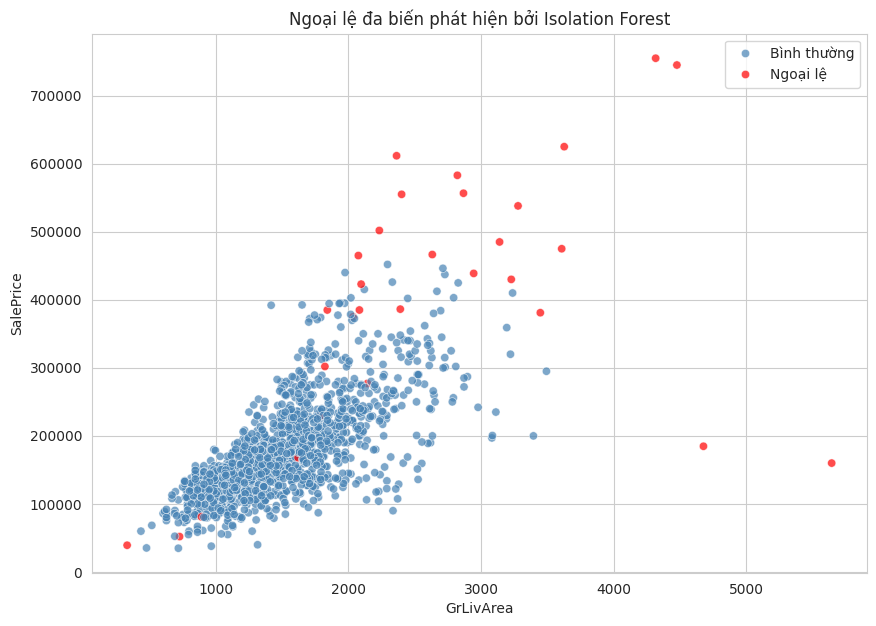

,Id,GrLivArea,OverallQual,TotalBsmtSF,SalePrice
533,534,334,1,0,39300
710,711,729,3,270,52000
1061,1062,894,3,894,81000
1298,1299,5642,10,6110,160000
1190,1191,1622,4,1249,168000
523,524,4676,10,3138,184750
335,336,1786,5,1499,228950
249,250,2144,6,1444,277000
706,707,1824,7,1643,302000
313,314,2036,7,2136,375000


In [120]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='GrLivArea', y='SalePrice', hue=train['iso_outlier'].map({1: 'Bình thường', -1: 'Ngoại lệ'}),
                 data=train, palette={'Bình thường': 'steelblue', 'Ngoại lệ': 'red'}, alpha=0.7)
plt.title('Ngoại lệ đa biến phát hiện bởi Isolation Forest')
plt.legend(title='')
plt.show()

train[train['iso_outlier'] == -1][['Id', 'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'SalePrice']].sort_values('SalePrice')


## 6. Tổng hợp & đề xuất danh sách loại bỏ

So sánh 3 phương pháp: (1) gợi ý của paper (`GrLivArea > 4000`), (2) IQR trên `GrLivArea`/`SalePrice`, (3) Isolation Forest đa biến.

In [121]:
candidate_outliers = set(outliers_paper['Id']) | set(train[train['iso_outlier'] == -1]['Id'])

summary_outliers = train[train['Id'].isin(candidate_outliers)][
    ['Id', 'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'SalePrice', 'SaleCondition']
].copy()
summary_outliers['flag_paper_GrLivArea>4000'] = summary_outliers['Id'].isin(outliers_paper['Id'])
summary_outliers['flag_isolation_forest'] = summary_outliers['Id'].isin(
    train[train['iso_outlier'] == -1]['Id']
)
summary_outliers.sort_values('GrLivArea', ascending=False)


,Id,GrLivArea,OverallQual,TotalBsmtSF,SalePrice,SaleCondition,flag_paper_GrLivArea>4000,flag_isolation_forest
1298,1299,5642,10,6110,160000,Partial,True,True
523,524,4676,10,3138,184750,Partial,True,True
1182,1183,4476,10,2396,745000,Abnorml,True,True
691,692,4316,10,2444,755000,Normal,True,True
1169,1170,3627,10,1930,625000,Normal,False,True
185,186,3608,10,1107,475000,Normal,False,True
1268,1269,3447,8,728,381000,Normal,False,True
769,770,3279,8,1650,538000,Normal,False,True
496,497,3228,8,3200,430000,Normal,False,True
798,799,3140,9,1926,485000,Partial,False,True
